<h1 align="center" id="top"><u>RL project</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ | Fanny BADOULES | Ghiles KEMICHE</u></h3>
<h3 align="center"><u>Groupe 4</u></h3>

# Table des matières
***
1. [Import](#import)
2. [Courbes d'entraînement](#courbes-dentraînement)
3. [Comparaison DQN vs Stable-Baselines vs Double DQN (extension) à configuration, seeds et métriques identiques : évaluation](#comparaison-dqn-vs-stable-baselines-vs-double-dqn-extension-à-configuration-seeds-et-métriques-identiques--évaluation)
4. [Comparaison des différentes configuration (extension) : évaluation](#comparaison-des-différentes-configuration-extension--évaluation)
5. [Etude de l'extension complète](#etude-de-lextension-complète)
6. [Etude d'un cas d'échec et interprétation](#etude-dun-cas-déchec-et-interprétation)
7. [Analyse du comportement du modèle à partir d'un rollout sélectionné](#analyse-du-comportement-du-modèle-à-partir-dun-rollout-sélectionné)
8. [Discussion des choix de conception](#discussion-des-choix-de-conception)

Remarque : notre extension qui consiste à l'étude d'un double DQN et de différente configuation est directement comparée dans ce notebook avec nos modèles de la Core task.

## Import
***

In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rl_project.benchmark.benchmark import HighwayBenchmark
from rl_project.benchmark.typing import BenchmarkConfig
from rl_project.models.core.typing import ModelType
from rl_project.models.factory import load_model
from scripts.envs.factory import get_env_config
from scripts.envs.typing import EnvType
from scripts.utils.cache import CacheManager
from scripts.utils.display import display_episode

Chargement des csv de training et d'évaluation :

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


def build_dataframe_name(csv_path: Path, data_dir: Path) -> str:
    relative_parts = csv_path.relative_to(data_dir).with_suffix("").parts
    sanitized_parts = [part.replace("-", "_") for part in relative_parts]
    return "_".join(sanitized_parts) + "_df"


def resolve_model_path(
    project_root: Path,
    model_type: ModelType,
    env_type: EnvType,
    train_seed: int,
    checkpoint: int | None = None,
) -> Path:
    model_dir = (
        project_root
        / "data"
        / "training"
        / model_type.value
        / env_type.value
        / f"seed_{train_seed}"
    )

    if checkpoint is None:
        matches = sorted(
            model_dir.glob(f"model_{model_type.value}_{env_type.value}_seed_{train_seed}_*.pt"),
        )
        if not matches:
            matches = sorted(model_dir.glob("model*.pt"))
    else:
        matches = sorted(model_dir.glob(f"checkpoint*ep_{checkpoint}.pt"))
        if not matches:
            matches = sorted(model_dir.glob(f"checkpoint*episode_{checkpoint}.pt"))

    if not matches:
        raise FileNotFoundError(f"No model file found in {model_dir}")
    return matches[0]


project_root = find_project_root(Path.cwd())
data_dir = project_root / "data"

loaded_dataframes = {}

for csv_path in sorted(data_dir.rglob("*.csv")):
    dataframe_name = build_dataframe_name(csv_path, data_dir)
    dataframe = CacheManager.load(csv_path)
    loaded_dataframes[dataframe_name] = dataframe
    globals()[dataframe_name] = dataframe

len(sorted(loaded_dataframes))

36

## Courbes d'entraînement
***

### Chargement et traitement des données d'entraînement

In [3]:
sns.set_theme(style="whitegrid", context="talk")

TRAINING_KEY_PATTERN = re.compile(
    r"^training_(?P<model>[^_]+)_(?P<config>[^_]+)_seed_(?P<seed>\d+)_.*_df$",
)
TRAINING_STEP_BUDGET = 200_000


def to_episode_history(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.copy()

    if "step" in frame.columns and "episode" in frame.columns:
        episode_history = (
            frame.groupby("episode", as_index=False)
            .agg(
                reward=("reward", "sum"),
                length=("step_in_episode", "max"),
                crashed=("crashed", "max"),
                offroad=("offroad", "max"),
                mean_speed=("speed", "mean"),
                total_steps=("step", "max"),
            )
            .sort_values("episode")
            .reset_index(drop=True)
        )
        episode_history["episode"] = episode_history["episode"] + 1
        episode_history["length"] = episode_history["length"] + 1
        episode_history["total_steps"] = episode_history["total_steps"] + 1
    elif {"episode", "reward", "length"}.issubset(frame.columns):
        episode_history = frame.sort_values("episode").reset_index(drop=True).copy()
    else:
        raise ValueError(f"Unsupported training history schema: {frame.columns.tolist()}")

    if "total_steps" not in episode_history.columns:
        episode_history["total_steps"] = episode_history["length"].cumsum()

    for column in ["crashed", "offroad"]:
        if column in episode_history.columns:
            episode_history[column] = episode_history[column].astype(float)

    return episode_history


training_runs = []

for dataframe_name, df in loaded_dataframes.items():
    match = TRAINING_KEY_PATTERN.match(dataframe_name)
    if match is None:
        continue

    metadata = match.groupdict()
    episode_history = to_episode_history(df)
    episode_history["model"] = metadata["model"].upper()
    episode_history["config"] = metadata["config"].capitalize()
    episode_history["seed"] = int(metadata["seed"])
    training_runs.append(episode_history)

training_history = pd.concat(training_runs, ignore_index=True)

rolling_window = 20
for source_col, smooth_col in [
    ("reward", "reward_smooth"),
    ("crashed", "crash_rate_smooth"),
    ("offroad", "offroad_rate_smooth"),
    ("mean_speed", "mean_speed_smooth"),
]:
    training_history[smooth_col] = training_history.groupby(["model", "config", "seed"])[
        source_col
    ].transform(lambda s: s.rolling(window=min(rolling_window, len(s)), min_periods=1).mean())

training_summary = (
    training_history.groupby(["model", "config", "seed"], as_index=False)
    .agg(
        mean_reward=("reward", "mean"),
        mean_episode_length=("length", "mean"),
        crash_rate=("crashed", "mean"),
        offroad_rate=("offroad", "mean"),
        mean_speed=("mean_speed", "mean"),
        observed_steps=("total_steps", "max"),
        observed_episodes=("episode", "max"),
    )
    .sort_values(["config", "model", "seed"])
)
training_summary["steps_below_200k"] = training_summary["observed_steps"] < TRAINING_STEP_BUDGET
training_summary["step_note"] = np.where(
    training_summary["steps_below_200k"],
    "short run: "
    + training_summary["observed_steps"].round().astype(int).astype(str)
    + f"/{TRAINING_STEP_BUDGET} steps",
    "OK",
)

display(training_summary)

,model,config,seed,mean_reward,mean_episode_length,crash_rate,offroad_rate,mean_speed,observed_steps,observed_episodes,steps_below_200k,step_note
0,2DQN,Baseline,1,19.783023,28.332625,0.111347,0.0,20.995838,200000,7059,False,OK
1,2DQN,Baseline,2,19.683159,28.149191,0.123575,0.0,21.041359,200000,7105,False,OK
2,2DQN,Baseline,3,19.795095,28.336639,0.110938,0.0,21.006197,200000,7058,False,OK
3,DQN,Baseline,1,19.774837,28.409091,0.102699,0.0,20.911995,200000,7040,False,OK
4,DQN,Baseline,2,19.867092,28.473804,0.095814,0.0,20.962513,200000,7024,False,OK
5,DQN,Baseline,3,19.869595,28.506271,0.102052,0.0,20.924054,200000,7016,False,OK
15,SB3,Baseline,1,17.564479,19.323671,0.710145,0.0,27.729303,200000,10350,False,OK
16,SB3,Baseline,2,17.349876,18.901805,0.729515,0.0,27.949273,200000,10581,False,OK
17,SB3,Baseline,3,18.170912,19.857029,0.671565,0.0,27.809241,200000,10072,False,OK
6,DQN,Dense,1,13.774455,24.408103,0.442641,0.0,20.372445,200000,8194,False,OK


### Graphes par seed

#### Comparaison des modèles SB3, DQN et 2DQN (baseline)

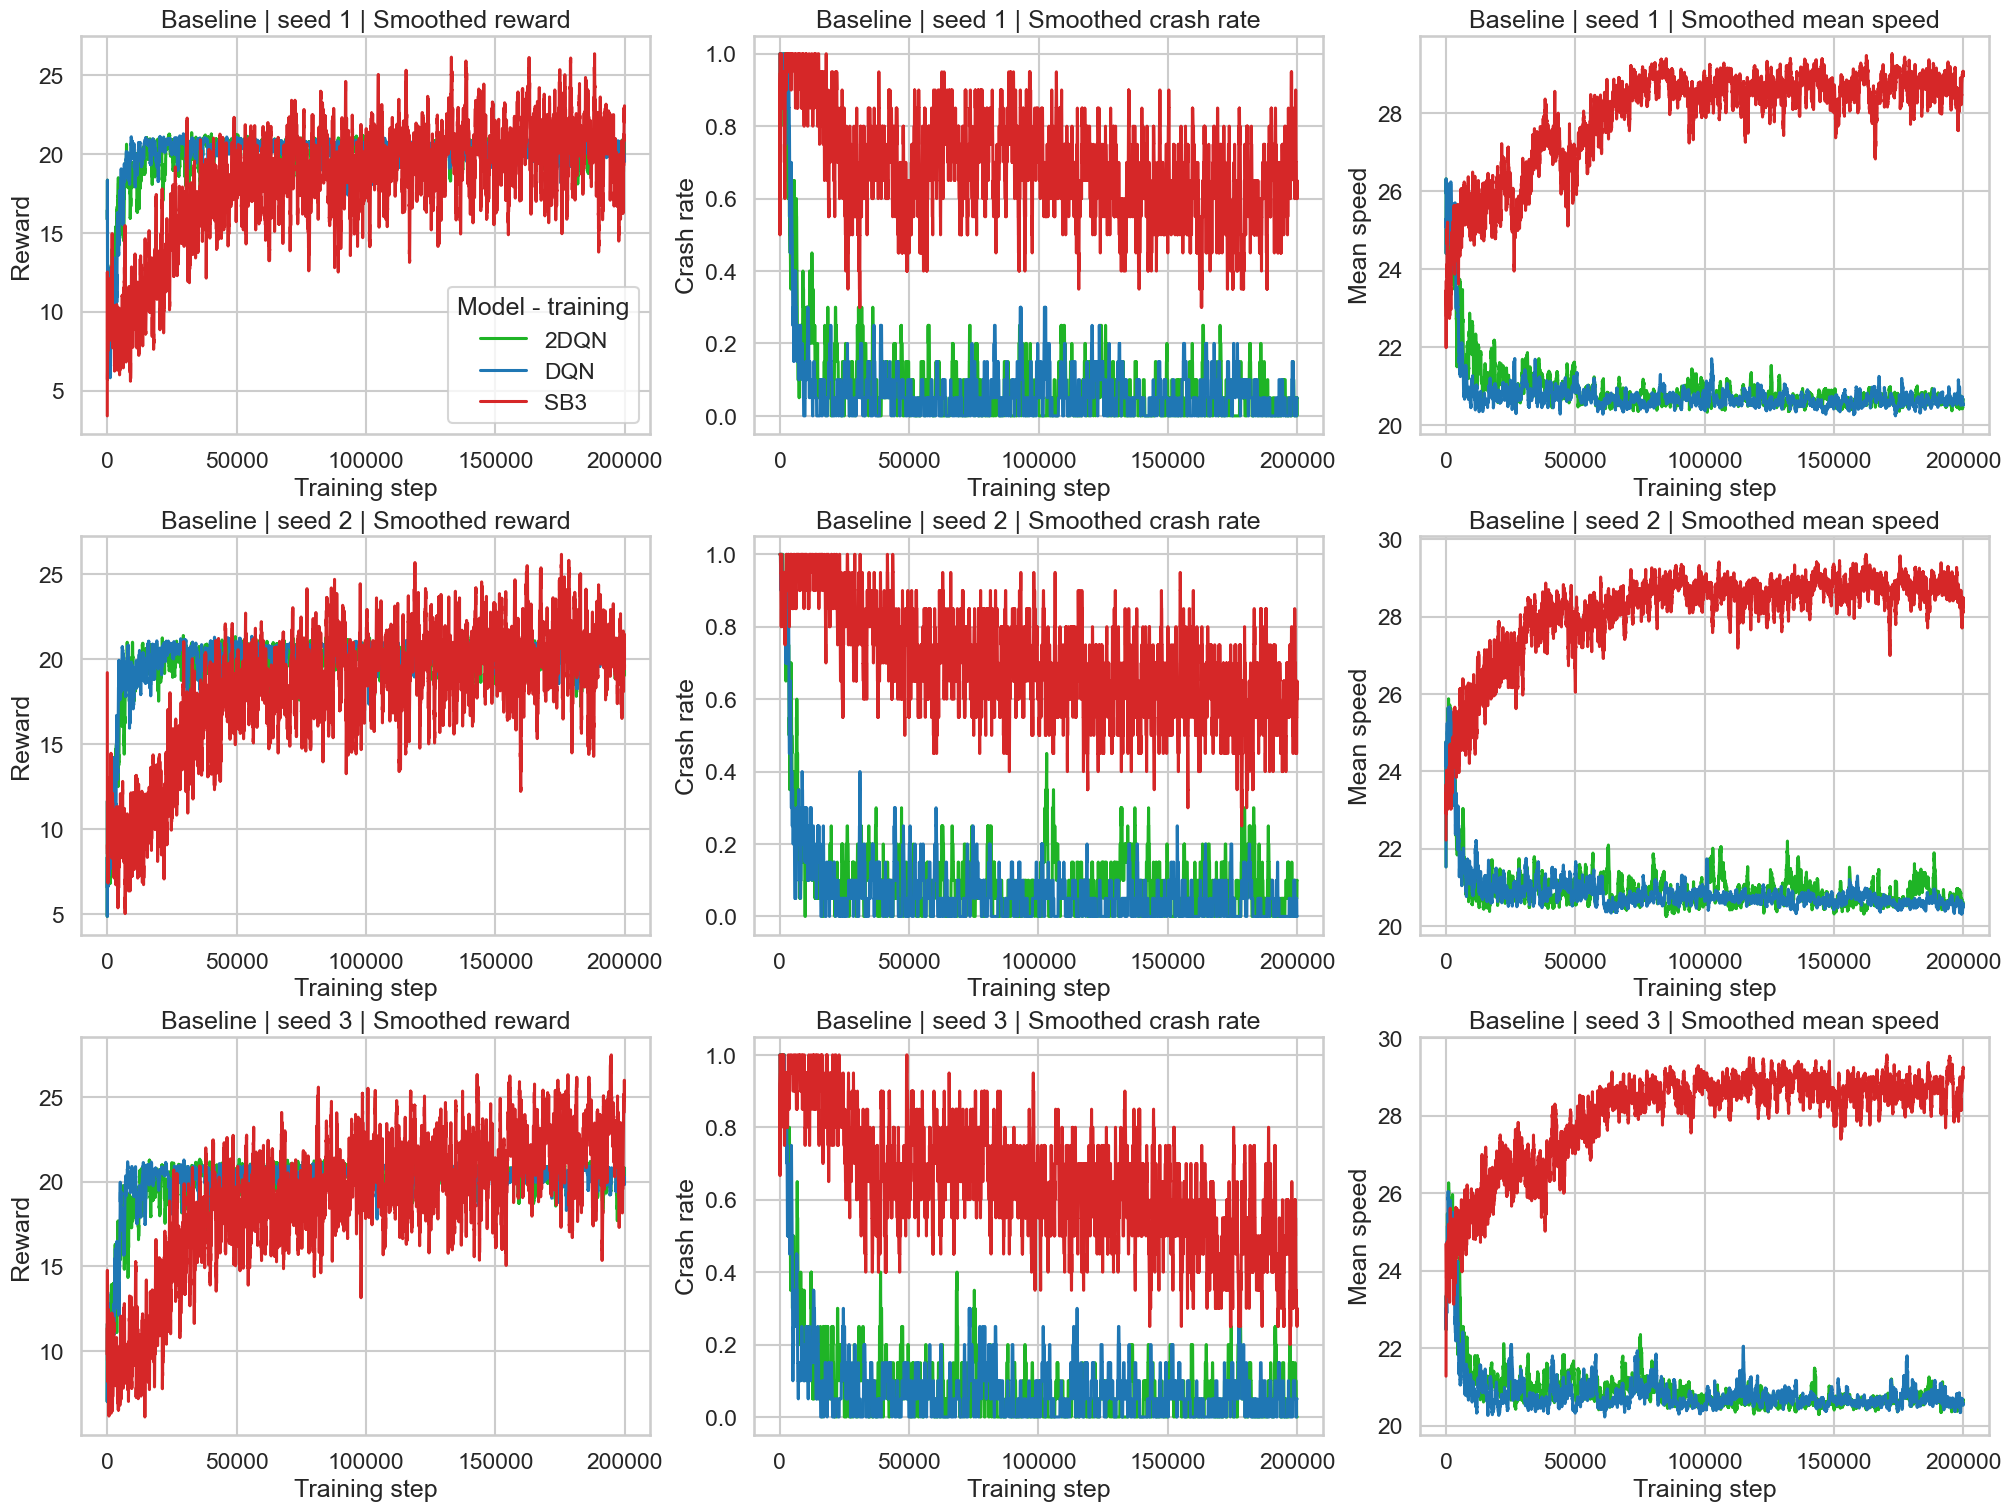

In [4]:
baseline_seed_training = training_history[
    (training_history["config"] == "Baseline")
    & (training_history["model"].isin(["DQN", "2DQN", "SB3"]))
].copy()

seeds = sorted(baseline_seed_training["seed"].unique())
palette = {"DQN": "#1f77b4", "SB3": "#d62728", "2DQN": "#1fb426"}

plot_specs = [
    ("reward_smooth", "Smoothed reward", "Reward"),
    ("crash_rate_smooth", "Smoothed crash rate", "Crash rate"),
    ("mean_speed_smooth", "Smoothed mean speed", "Mean speed"),
]

fig, axes = plt.subplots(
    nrows=len(seeds),
    ncols=len(plot_specs),
    figsize=(20, 5 * len(seeds)),
    sharex=False,
    constrained_layout=True,
)

if len(seeds) == 1:
    axes = np.array([axes])

for row_idx, seed in enumerate(seeds):
    seed_data = baseline_seed_training[baseline_seed_training["seed"] == seed]

    for col_idx, (smooth_col, title, ylabel) in enumerate(plot_specs):
        ax = axes[row_idx, col_idx]

        for model, model_df in seed_data.groupby("model"):
            model_df = model_df.sort_values("total_steps")
            ax.plot(
                model_df["total_steps"],
                model_df[smooth_col],
                color=palette[model],
                linewidth=2.2,
                label=model,
            )

        ax.set_title(f"Baseline | seed {seed} | {title}")
        ax.set_xlabel("Training step")
        ax.set_ylabel(ylabel)

        if row_idx == 0 and col_idx == 0:
            ax.legend(title="Model - training")
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

plt.show()

Sur la configuration baseline, les trois modèles apprennent des comportements assez différents.

DQN et 2DQN ont des courbes très proches. Leur reward monte rapidement au début de l'entraînement puis se stabilise autour de 20. Leur crash rate devient rapidement faible, et leur vitesse moyenne reste autour de 20-21. Cela montre que ces deux modèles apprennent une politique prudente : ils privilégient la stabilité et la sécurité plutôt que la vitesse.

SB3 suit une dynamique différente. Son reward démarre plus bas, puis augmente progressivement et finit par dépasser DQN et 2DQN sur plusieurs seeds. Mais cette amélioration vient avec une vitesse moyenne beaucoup plus élevée, autour de 28-29, et surtout avec un crash rate nettement plus important. Même en fin d'entraînement, SB3 garde un comportement plus instable et plus risqué.

Les résultats sont cohérents sur les trois seeds : DQN et 2DQN sont plus sûrs et plus réguliers, tandis que SB3 apprend une politique plus rapide et plus agressive. La différence principale n'est donc pas seulement le reward, mais le compromis appris par chaque modèle : SB3 maximise davantage la vitesse et la performance, alors que DQN et 2DQN restent plus conservateurs.

#### Comparaison des configurations

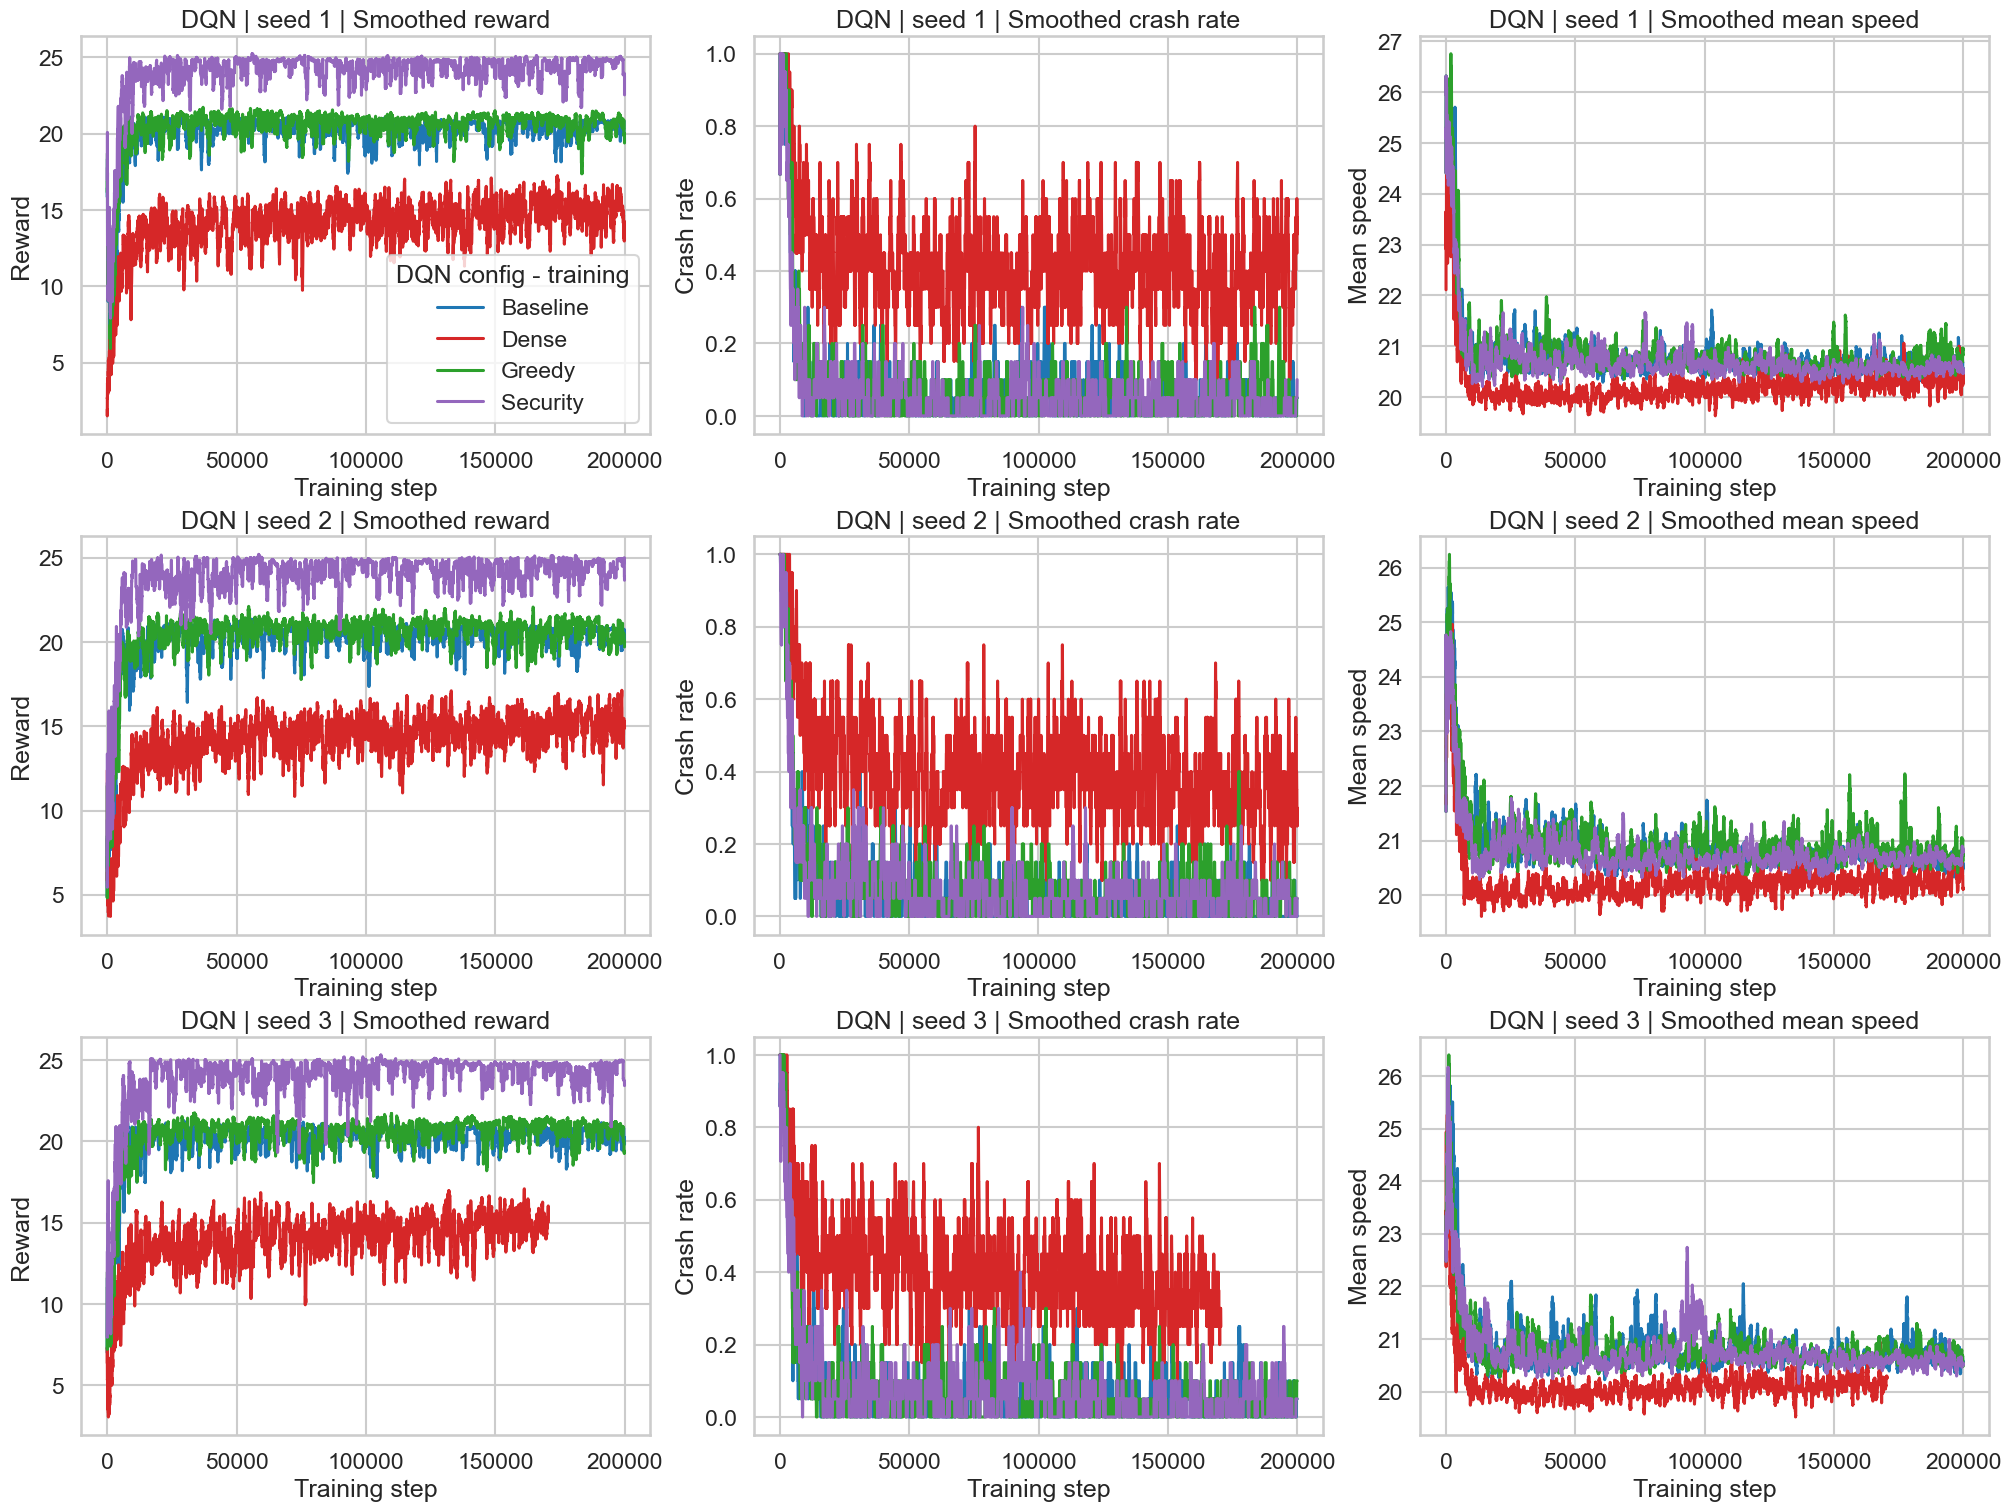

In [5]:
dqn_config_seed_training = training_history[
    (training_history["model"] == "DQN")
    & (training_history["config"].isin(["Baseline", "Greedy", "Dense", "Security"]))
].copy()

seeds = sorted(dqn_config_seed_training["seed"].unique())
config_palette = {
    "Baseline": "#1f77b4",
    "Greedy": "#2ca02c",
    "Dense": "#d62728",
    "Security": "#9467bd",
}

plot_specs = [
    ("reward_smooth", "Smoothed reward", "Reward"),
    ("crash_rate_smooth", "Smoothed crash rate", "Crash rate"),
    ("mean_speed_smooth", "Smoothed mean speed", "Mean speed"),
]

fig, axes = plt.subplots(
    nrows=len(seeds),
    ncols=len(plot_specs),
    figsize=(20, 5 * len(seeds)),
    sharex=False,
    constrained_layout=True,
)

if len(seeds) == 1:
    axes = np.array([axes])

for row_idx, seed in enumerate(seeds):
    seed_data = dqn_config_seed_training[dqn_config_seed_training["seed"] == seed]

    for col_idx, (smooth_col, title, ylabel) in enumerate(plot_specs):
        ax = axes[row_idx, col_idx]

        for config, config_df in seed_data.groupby("config"):
            config_df = config_df.sort_values("total_steps")
            ax.plot(
                config_df["total_steps"],
                config_df[smooth_col],
                color=config_palette[config],
                linewidth=2.2,
                label=config,
            )

        ax.set_title(f"DQN | seed {seed} | {title}")
        ax.set_xlabel("Training step")
        ax.set_ylabel(ylabel)

        if row_idx == 0 and col_idx == 0:
            ax.legend(title="DQN config - training")
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

plt.show()

Les quatre configurations DQN donnent des comportements assez différents pendant l'entraînement ce qui est attendu puisque chacune repose sur une fonction de reward spécifique. 

La configuration Security est celle qui obtient les meilleurs rewards sur les trois seeds. Elle monte rapidement puis se stabilise autour de 24-25, tout en gardant un crash rate faible après le début de l'entraînement. C'est donc la configuration la plus efficace par rapport a sa configuration de training.

Les configurations Baseline et Greedy sont quant à elles très proches. Elles atteignent toutes les deux un reward autour de 20-21, avec un crash rate globalement faible et leur vitesse moyenne reste aussi autour de 20-21. On peut donc remarquer qu'elles apprennent une conduite assez stable, mais moins performante que Security pour leur configuration.

La configuration Dense est clairement la moins bonne pour sa configuration puisque son reward reste plus bas, autour de 14-16, et son crash rate reste beaucoup plus élevé que les autres configurations. Sa vitesse moyenne est légèrement plus basse, mais cela ne se traduit pas par plus de sécurité.

Ces résultats sont cohérents puisque comme on a pu le voir notre modèle de DQN a tendence a apprendre une politique plus prudent et donc il est tout a fait cohérent d'avoir des reward plus elevé pour une configuration qui favorise ce genre de comportement. À l'inverse, il est intéressant de noter que même dans la configuration Greedy, censée encourager une conduite plus agressive, le modèle reste majoritairement prudent ce qui limite sa capacité à exploiter pleinement cette configuration et explique les performances observées.

### Graphes agrégés

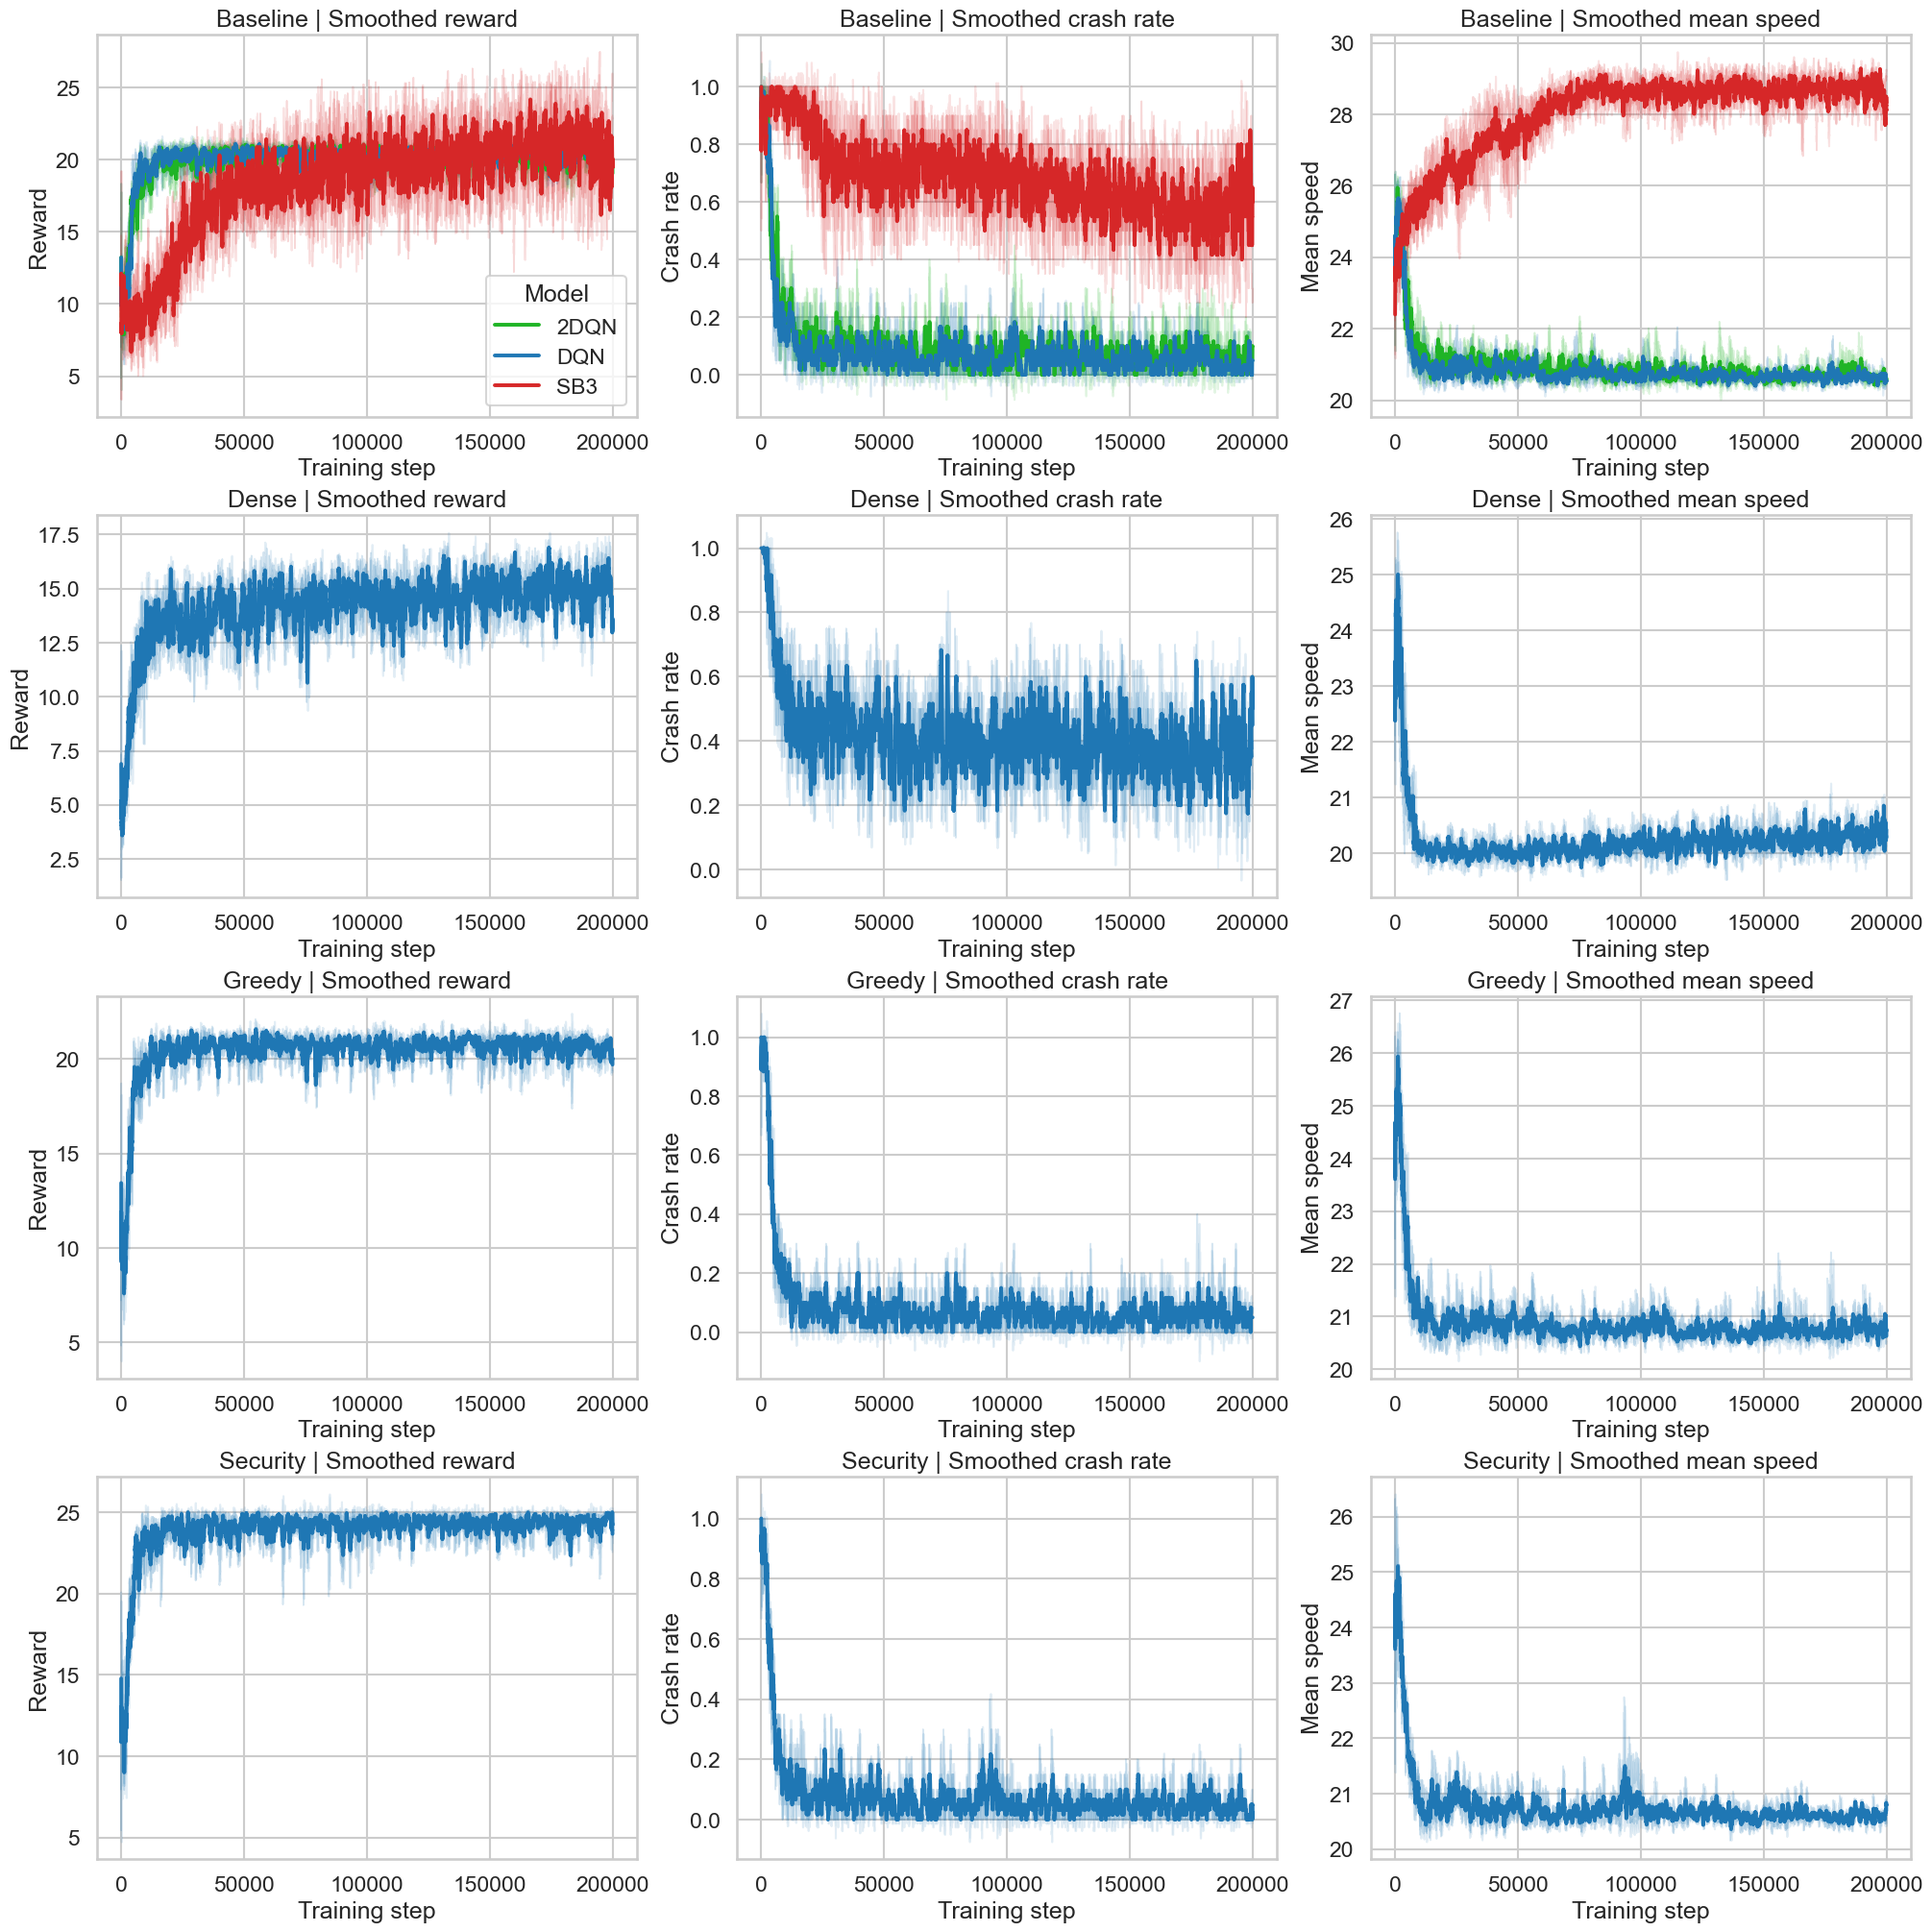

In [ ]:
plot_data = (
    training_history.groupby(["config", "model", "episode"], as_index=False)
    .agg(
        reward_mean=("reward_smooth", "mean"),
        reward_std=("reward_smooth", "std"),
        crash_mean=("crash_rate_smooth", "mean"),
        crash_std=("crash_rate_smooth", "std"),
        speed_mean=("mean_speed_smooth", "mean"),
        speed_std=("mean_speed_smooth", "std"),
        step_mean=("total_steps", "mean"),
        n_runs=("seed", "nunique"),
    )
    .fillna(0.0)
)

configs = sorted(training_history["config"].unique())
palette = {"DQN": "#1f77b4", "SB3": "#d62728", "2DQN": "#1fb426"}
plot_specs = [
    ("reward", "Smoothed reward", "Reward"),
    ("crash", "Smoothed crash rate", "Crash rate"),
    ("speed", "Smoothed mean speed", "Mean speed"),
]

fig, axes = plt.subplots(
    nrows=len(configs),
    ncols=len(plot_specs),
    figsize=(20, 5 * len(configs)),
    sharex=False,
    constrained_layout=True,
)

if len(configs) == 1:
    axes = np.array([axes])

for row_idx, config in enumerate(configs):
    config_seed_data = training_history[training_history["config"] == config]
    config_mean_data = plot_data[plot_data["config"] == config]

    for col_idx, (metric_prefix, title, ylabel) in enumerate(plot_specs):
        ax = axes[row_idx, col_idx]
        mean_col = f"{metric_prefix}_mean"
        std_col = f"{metric_prefix}_std"
        smooth_col = {
            "reward": "reward_smooth",
            "crash": "crash_rate_smooth",
            "speed": "mean_speed_smooth",
        }[metric_prefix]

        for (model, _), seed_df in config_seed_data.groupby(["model", "seed"]):
            ax.plot(
                seed_df["total_steps"],
                seed_df[smooth_col],
                color=palette[model],
                alpha=0.18,
                linewidth=1.2,
            )

        for model, model_df in config_mean_data.groupby("model"):
            model_df = model_df.sort_values("episode")
            ax.plot(
                model_df["step_mean"],
                model_df[mean_col],
                color=palette[model],
                linewidth=2.8,
                label=model,
            )
            ax.fill_between(
                model_df["step_mean"],
                model_df[mean_col] - model_df[std_col],
                model_df[mean_col] + model_df[std_col],
                color=palette[model],
                alpha=0.12,
            )

        ax.set_title(f"{config} | {title}")
        ax.set_xlabel("Training step")
        ax.set_ylabel(ylabel)
        if row_idx == 0 and col_idx == 0:
            ax.legend(title="Model")
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

plt.show()

## Comparaison DQN vs Stable-Baselines vs Double DQN (extension) à configuration, seeds et métriques identiques : évaluation
***

### Chargement et traitement des données d'évaluation

In [7]:
summary_pattern = re.compile(
    r"data[\\/]evaluation[\\/](?P<model>[^\\/]+)[\\/](?P<config>[^\\/]+)[\\/]seed_(?P<train_seed>\d+)[\\/]evaluation_summary\.json$",
)

METRICS_TO_COMPARE = [
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "crash_rate",
    "offroad_rate",
    "mean_speed",
]
REQUIRED_COMPARISON_MODELS = {"DQN", "SB3", "2DQN"}
ALL_COMPARISON_MODELS = ["DQN", "SB3", "2DQN"]

summary_records = []
for summary_path in sorted((data_dir / "evaluation").rglob("evaluation_summary.json")):
    match = summary_pattern.search(str(summary_path))
    if match is None:
        continue

    metadata = match.groupdict()
    summary = CacheManager.load(summary_path)
    summary_records.append(
        {
            "model": metadata["model"].upper(),
            "config": metadata["config"].capitalize(),
            "train_seed": int(metadata["train_seed"]),
            **summary,
        },
    )

if not summary_records:
    raise ValueError("No evaluation_summary.json files found under data/evaluation")

evaluation_summary_df = pd.DataFrame(summary_records).sort_values(["config", "model", "train_seed"])

common_summary_pairs = (
    evaluation_summary_df.groupby(["config", "train_seed"])["model"]
    .agg(lambda models: REQUIRED_COMPARISON_MODELS.issubset(set(models)))
    .reset_index(name="has_required_models")
    .query("has_required_models")[["config", "train_seed"]]
)

paired_summary_df = evaluation_summary_df.merge(
    common_summary_pairs,
    on=["config", "train_seed"],
    how="inner",
)
paired_summary_df = paired_summary_df[paired_summary_df["model"].isin(ALL_COMPARISON_MODELS)].copy()

paired_inventory = (
    paired_summary_df.groupby(["config", "model"], as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        train_seeds=("train_seed", lambda s: sorted(int(v) for v in s)),
        n_episodes_values=("n_episodes", lambda s: sorted(int(v) for v in set(s))),
    )
    .sort_values(["config", "model"])
)

display(paired_inventory)

,config,model,n_training_seeds,train_seeds,n_episodes_values
0,Baseline,2DQN,3,"[1, 2, 3]",[50]
1,Baseline,DQN,3,"[1, 2, 3]",[50]
2,Baseline,SB3,3,"[1, 2, 3]",[50]


### Tableau par seed

In [8]:
paired_summary_comparison = paired_summary_df.pivot_table(
    index=["config", "train_seed"],
    columns="model",
    values=[*METRICS_TO_COMPARE, "n_episodes"],
)
paired_summary_comparison.columns = [
    f"{metric}_{model}" for metric, model in paired_summary_comparison.columns
]
paired_summary_comparison = paired_summary_comparison.reset_index()

for model in ["SB3", "2DQN"]:
    model_suffix = model.lower()
    for metric in METRICS_TO_COMPARE:
        paired_summary_comparison[f"delta_{metric}_dqn_minus_{model_suffix}"] = (
            paired_summary_comparison[f"{metric}_DQN"]
            - paired_summary_comparison[f"{metric}_{model}"]
        )

per_seed_display_columns = ["config", "train_seed"]
for metric in [
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "crash_rate",
    "offroad_rate",
    "mean_speed",
    "n_episodes",
]:
    per_seed_display_columns.extend([f"{metric}_DQN", f"{metric}_SB3", f"{metric}_2DQN"])

for model in ["SB3", "2DQN"]:
    model_suffix = model.lower()
    per_seed_display_columns.extend(
        [
            f"delta_mean_reward_dqn_minus_{model_suffix}",
            f"delta_crash_rate_dqn_minus_{model_suffix}",
            f"delta_mean_speed_dqn_minus_{model_suffix}",
        ],
    )

per_seed_comparison_table = paired_summary_comparison[per_seed_display_columns].sort_values(
    ["config", "train_seed"],
)

display(per_seed_comparison_table.round(3))

,config,train_seed,mean_reward_DQN,mean_reward_SB3,mean_reward_2DQN,std_reward_DQN,std_reward_SB3,std_reward_2DQN,mean_episode_length_DQN,mean_episode_length_SB3,...,mean_speed_2DQN,n_episodes_DQN,n_episodes_SB3,n_episodes_2DQN,delta_mean_reward_dqn_minus_sb3,delta_crash_rate_dqn_minus_sb3,delta_mean_speed_dqn_minus_sb3,delta_mean_reward_dqn_minus_2dqn,delta_crash_rate_dqn_minus_2dqn,delta_mean_speed_dqn_minus_2dqn
0,Baseline,1,20.741,21.163,20.732,0.756,9.130,0.207,29.86,22.14,...,20.550,50.0,50.0,50.0,-0.422,-0.50,-8.141,0.009,0.02,0.156
1,Baseline,2,20.396,22.323,20.797,1.528,8.854,0.270,29.56,23.16,...,20.649,50.0,50.0,50.0,-1.926,-0.44,-8.694,-0.401,0.06,-0.149
2,Baseline,3,20.345,24.241,20.736,2.437,8.150,0.276,29.34,24.96,...,20.547,50.0,50.0,50.0,-3.896,-0.38,-8.623,-0.391,0.04,0.124


### Graphes par seed

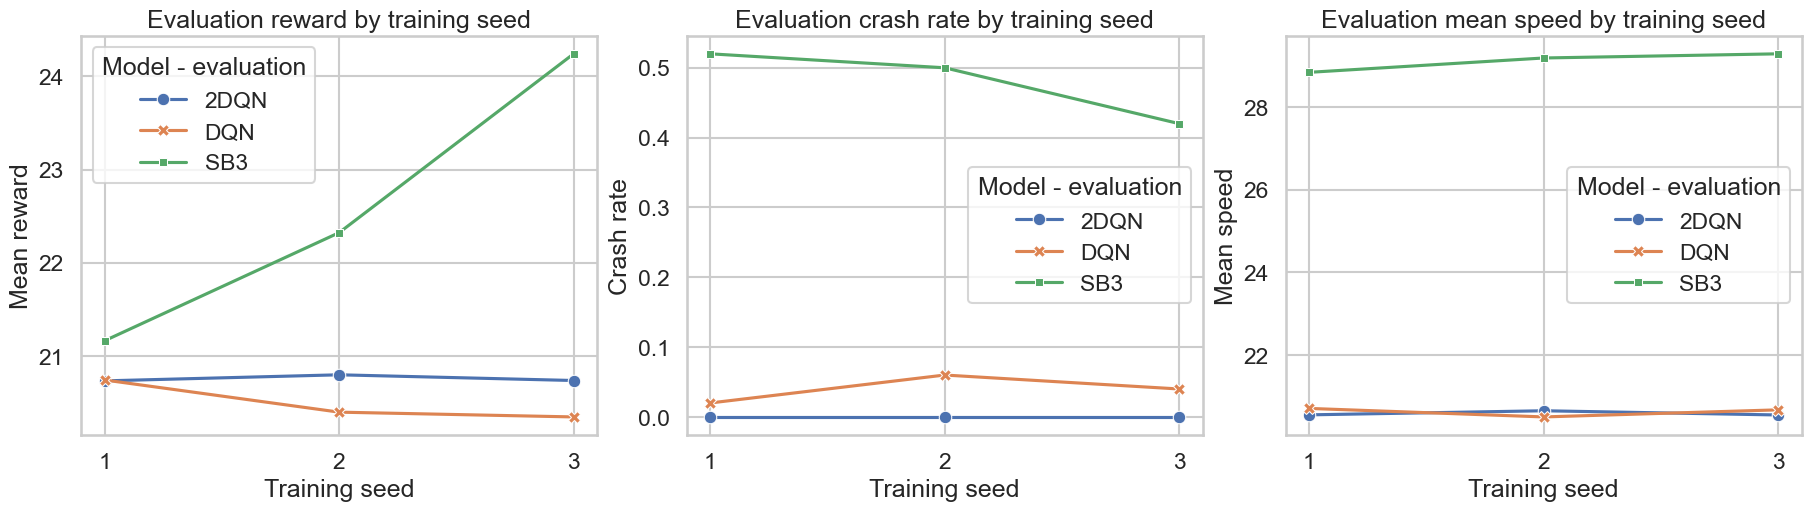

In [19]:
per_seed_plot_df = paired_summary_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

plot_specs = [
    ("mean_reward", "Evaluation reward by training seed", "Mean reward"),
    ("crash_rate", "Evaluation crash rate by training seed", "Crash rate"),
    ("mean_speed", "Evaluation mean speed by training seed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    sns.lineplot(
        data=per_seed_plot_df,
        x="train_seed",
        y=metric,
        hue="model",
        style="model",
        markers=True,
        dashes=False,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(per_seed_plot_df["train_seed"].unique()))
    ax.legend(title="Model - evaluation")

plt.show()

Tous les modèles sont ici comparés dans les mêmes conditions d'évaluation (sur la configuration de base) indépendamment de leur configuration d'entraînement. On peut donc rapidement remarquer que les 3 modèles gardent le meême comportmeent que pendant le training.

SB3 obtient le meilleur reward sur les trois seeds, et l'écart avec DQN augmente même entre la seed 1 et la seed 3. Il est aussi beaucoup plus rapide, avec une vitesse moyenne proche de 29, alors que DQN et 2DQN restent autour de 20 à 21.

En revanche, SB3 reste beaucoup moins sûr. Son crash rate est élevé sur toutes les seeds, entre 0.42 et 0.52. Cela confirme que son meilleur reward vient avec une prise de risque plus importante.

DQN et 2DQN ont des performances très proches en reward et en vitesse. La différence principale est la sécurité, 2DQN ne crash pas sur ces évaluations, alors que DQN garde quelques crashes. 2DQN apparaît donc comme la version la plus stable, même si elle ne gagne pas en reward.

La conclusion est que SB3 maximise davantage la performance et la vitesse, tandis que DQN et surtout 2DQN privilégient une conduite plus prudente et plus sûre.


### Tableau agrégé

In [9]:
summary_table = (
    paired_summary_df.groupby(["config", "model"], as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        reward_mean=("mean_reward", "mean"),
        reward_std_across_seeds=("mean_reward", "std"),
        mean_internal_std_reward=("std_reward", "mean"),
        episode_length_mean=("mean_episode_length", "mean"),
        crash_rate_mean=("crash_rate", "mean"),
        offroad_rate_mean=("offroad_rate", "mean"),
        mean_speed_mean=("mean_speed", "mean"),
        n_episodes=("n_episodes", "mean"),
    )
    .sort_values(["config", "model"])
    .fillna(0.0)
)

comparison_agg = {
    "paired_training_seeds": ("train_seed", "nunique"),
    "reward_delta_mean_dqn_minus_sb3": ("delta_mean_reward_dqn_minus_sb3", "mean"),
    "reward_delta_std_dqn_minus_sb3": ("delta_mean_reward_dqn_minus_sb3", "std"),
    "std_reward_delta_mean_dqn_minus_sb3": ("delta_std_reward_dqn_minus_sb3", "mean"),
    "episode_length_delta_mean_dqn_minus_sb3": (
        "delta_mean_episode_length_dqn_minus_sb3",
        "mean",
    ),
    "crash_rate_delta_mean_dqn_minus_sb3": ("delta_crash_rate_dqn_minus_sb3", "mean"),
    "offroad_rate_delta_mean_dqn_minus_sb3": ("delta_offroad_rate_dqn_minus_sb3", "mean"),
    "mean_speed_delta_mean_dqn_minus_sb3": ("delta_mean_speed_dqn_minus_sb3", "mean"),
    "reward_delta_mean_dqn_minus_2dqn": ("delta_mean_reward_dqn_minus_2dqn", "mean"),
    "reward_delta_std_dqn_minus_2dqn": ("delta_mean_reward_dqn_minus_2dqn", "std"),
    "std_reward_delta_mean_dqn_minus_2dqn": ("delta_std_reward_dqn_minus_2dqn", "mean"),
    "episode_length_delta_mean_dqn_minus_2dqn": (
        "delta_mean_episode_length_dqn_minus_2dqn",
        "mean",
    ),
    "crash_rate_delta_mean_dqn_minus_2dqn": ("delta_crash_rate_dqn_minus_2dqn", "mean"),
    "offroad_rate_delta_mean_dqn_minus_2dqn": ("delta_offroad_rate_dqn_minus_2dqn", "mean"),
    "mean_speed_delta_mean_dqn_minus_2dqn": ("delta_mean_speed_dqn_minus_2dqn", "mean"),
    "n_episodes_dqn": ("n_episodes_DQN", "mean"),
    "n_episodes_sb3": ("n_episodes_SB3", "mean"),
    "n_episodes_2dqn": ("n_episodes_2DQN", "mean"),
}

comparison_table_json = (
    paired_summary_comparison.groupby("config", as_index=False)
    .agg(**comparison_agg)
    .sort_values("config")
    .fillna(0.0)
)

comparison_table_json["reward_delta_mean"] = comparison_table_json[
    "reward_delta_mean_dqn_minus_sb3"
]
comparison_table_json["crash_rate_delta_mean"] = comparison_table_json[
    "crash_rate_delta_mean_dqn_minus_sb3"
]
comparison_table_json["mean_speed_delta_mean"] = comparison_table_json[
    "mean_speed_delta_mean_dqn_minus_sb3"
]

comparison_table_json["better_model_on_reward_dqn_vs_sb3"] = np.where(
    comparison_table_json["reward_delta_mean_dqn_minus_sb3"] > 0,
    "DQN",
    np.where(comparison_table_json["reward_delta_mean_dqn_minus_sb3"] < 0, "SB3", "Tie"),
)
comparison_table_json["better_model_on_safety_dqn_vs_sb3"] = np.where(
    comparison_table_json["crash_rate_delta_mean_dqn_minus_sb3"] < 0,
    "DQN",
    np.where(comparison_table_json["crash_rate_delta_mean_dqn_minus_sb3"] > 0, "SB3", "Tie"),
)
comparison_table_json["better_model_on_reward_dqn_vs_2dqn"] = np.where(
    comparison_table_json["reward_delta_mean_dqn_minus_2dqn"] > 0,
    "DQN",
    np.where(comparison_table_json["reward_delta_mean_dqn_minus_2dqn"] < 0, "2DQN", "Tie"),
)
comparison_table_json["better_model_on_safety_dqn_vs_2dqn"] = np.where(
    comparison_table_json["crash_rate_delta_mean_dqn_minus_2dqn"] < 0,
    "DQN",
    np.where(comparison_table_json["crash_rate_delta_mean_dqn_minus_2dqn"] > 0, "2DQN", "Tie"),
)

comparison_table_json["episode_budget_check"] = np.where(
    comparison_table_json[["n_episodes_dqn", "n_episodes_sb3", "n_episodes_2dqn"]]
    .eq(50)
    .all(axis=1),
    "OK: 50 episodes",
    "Provisional: not 50 episodes yet",
)

display(summary_table.round(3))
display(comparison_table_json.round(3))

,config,model,n_training_seeds,reward_mean,reward_std_across_seeds,mean_internal_std_reward,episode_length_mean,crash_rate_mean,offroad_rate_mean,mean_speed_mean,n_episodes
0,Baseline,2DQN,3,20.755,0.037,0.251,30.000,0.00,0.0,20.582,50.0
1,Baseline,DQN,3,20.494,0.215,1.574,29.587,0.04,0.0,20.625,50.0
2,Baseline,SB3,3,22.576,1.555,8.711,23.420,0.48,0.0,29.111,50.0


,config,paired_training_seeds,reward_delta_mean_dqn_minus_sb3,reward_delta_std_dqn_minus_sb3,std_reward_delta_mean_dqn_minus_sb3,episode_length_delta_mean_dqn_minus_sb3,crash_rate_delta_mean_dqn_minus_sb3,offroad_rate_delta_mean_dqn_minus_sb3,mean_speed_delta_mean_dqn_minus_sb3,reward_delta_mean_dqn_minus_2dqn,...,n_episodes_sb3,n_episodes_2dqn,reward_delta_mean,crash_rate_delta_mean,mean_speed_delta_mean,better_model_on_reward_dqn_vs_sb3,better_model_on_safety_dqn_vs_sb3,better_model_on_reward_dqn_vs_2dqn,better_model_on_safety_dqn_vs_2dqn,episode_budget_check
0,Baseline,3,-2.082,1.742,-7.138,6.167,-0.44,0.0,-8.486,-0.261,...,50.0,50.0,-2.082,-0.44,-8.486,SB3,DQN,2DQN,2DQN,OK: 50 episodes


### Graphes agrégés

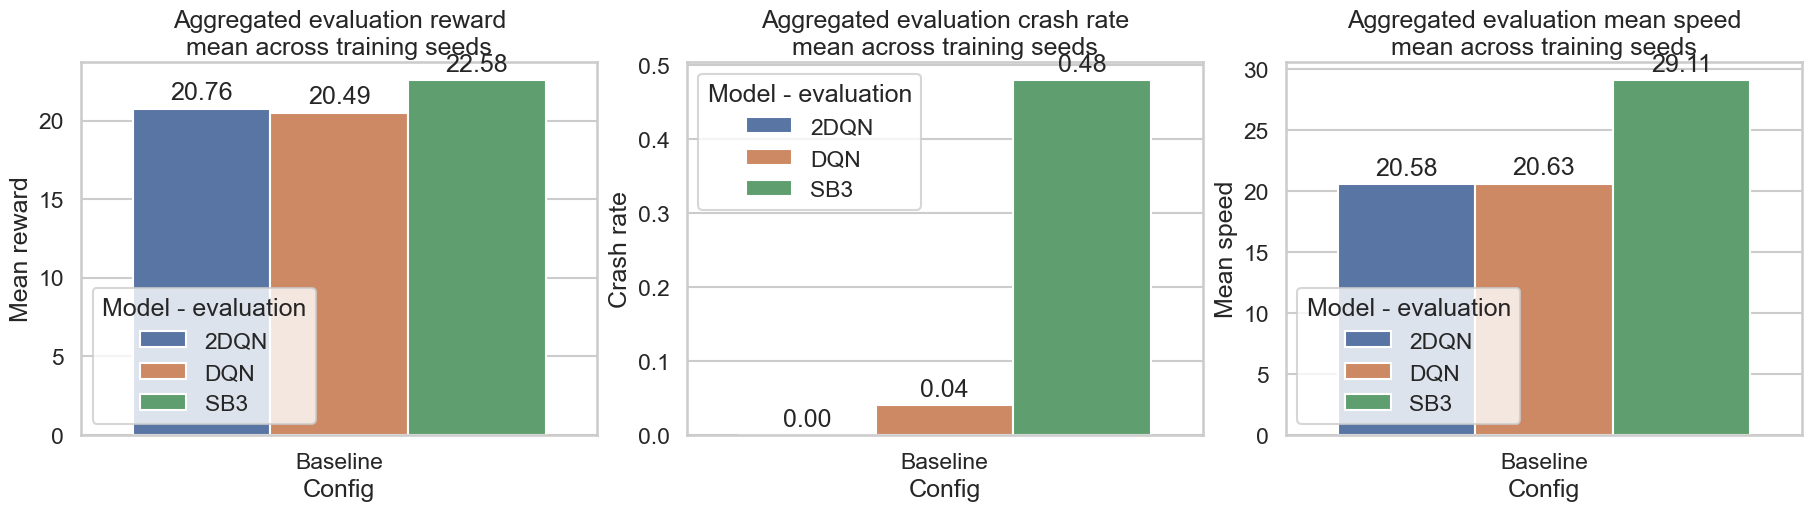

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

aggregate_plot_specs = [
    ("reward_mean", "Aggregated evaluation reward", "Mean reward"),
    ("crash_rate_mean", "Aggregated evaluation crash rate", "Crash rate"),
    ("mean_speed_mean", "Aggregated evaluation mean speed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, aggregate_plot_specs):
    sns.barplot(
        data=summary_table,
        x="config",
        y=metric,
        hue="model",
        ax=ax,
    )
    ax.set_title(title + "\nmean across training seeds")
    ax.set_xlabel("Config")
    ax.set_ylabel(ylabel)
    ax.legend(title="Model - evaluation")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

Ces graphes agrégés confirment le compromis observé précédemment.

Au global, SB3 est le plus performant en reward et en vitesse, mais 2DQN est le plus sûr. Cela confirme que le choix du modèle dépend de l'objectif : performance maximale avec SB3, ou conduite plus prudente avec 2DQN.

### Etude du meilleur modèle selon reward et sécurité

In [10]:
model_comparison_ranking = summary_table.copy()

model_comparison_ranking["reward_rank"] = model_comparison_ranking.groupby("config")[
    "reward_mean"
].rank(ascending=False, method="min")

model_comparison_ranking["safety_rank"] = model_comparison_ranking.groupby("config")[
    "crash_rate_mean"
].rank(ascending=True, method="min")

model_comparison_ranking["speed_rank"] = model_comparison_ranking.groupby("config")[
    "mean_speed_mean"
].rank(ascending=False, method="min")

model_comparison_ranking["overall_rank_score"] = (
    model_comparison_ranking["reward_rank"]
    + model_comparison_ranking["safety_rank"]
    + model_comparison_ranking["speed_rank"]
)

model_comparison_ranking = model_comparison_ranking.sort_values(
    ["config", "overall_rank_score", "reward_rank", "safety_rank"],
)

display(
    model_comparison_ranking[
        [
            "config",
            "model",
            "reward_mean",
            "crash_rate_mean",
            "mean_speed_mean",
            "reward_rank",
            "safety_rank",
            "speed_rank",
            "overall_rank_score",
        ]
    ].round(3),
)

,config,model,reward_mean,crash_rate_mean,mean_speed_mean,reward_rank,safety_rank,speed_rank,overall_rank_score
2,Baseline,SB3,22.576,0.48,29.111,1.0,3.0,1.0,5.0
0,Baseline,2DQN,20.755,0.00,20.582,2.0,1.0,3.0,6.0
1,Baseline,DQN,20.494,0.04,20.625,3.0,2.0,2.0,7.0


Ce classement résume le compromis entre performance, sécurité et vitesse.

SB3 arrive en premier au score global, car il est meilleur en reward et en vitesse. Cependant, ce résultat doit être nuancé : il est aussi le moins sûr, avec le crash rate le plus élevé.

2DQN arrive juste derrière. Il a un reward plus faible que SB3 et une vitesse plus basse, mais il est le meilleur sur la sécurité, avec aucun crash observé sur cette évaluation.

DQN est dernier dans ce classement, car il n'est premier sur aucun critère. Il reste néanmoins proche de 2DQN en reward et en vitesse, avec un crash rate faible.

## Comparaison des différentes configuration (extension) : évaluation
***

#### Traitement des données d'évaluation DQN par configuration

In [12]:
DQN_CONFIGS_TO_COMPARE = ["Baseline", "Greedy", "Dense", "Security"]
DQN_EVALUATION_METRICS = [
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "crash_rate",
    "offroad_rate",
    "mean_speed",
]

dqn_eval_summary_df = evaluation_summary_df[
    (evaluation_summary_df["model"] == "DQN")
    & (evaluation_summary_df["config"].isin(DQN_CONFIGS_TO_COMPARE))
].copy()

if dqn_eval_summary_df.empty:
    raise ValueError("No DQN evaluation summaries found for the selected configurations.")

dqn_eval_summary_df = dqn_eval_summary_df.sort_values(["config", "train_seed"])

display(dqn_eval_summary_df.round(3))

,model,config,train_seed,mean_reward,std_reward,mean_episode_length,crash_rate,offroad_rate,mean_speed,n_episodes
3,DQN,Baseline,1,20.741,0.756,29.86,0.02,0.0,20.705,50
4,DQN,Baseline,2,20.396,1.528,29.56,0.06,0.0,20.499,50
5,DQN,Baseline,3,20.345,2.437,29.34,0.04,0.0,20.671,50
6,DQN,Dense,1,20.455,0.000,30.00,0.00,0.0,20.034,50
7,DQN,Dense,2,20.455,0.000,30.00,0.00,0.0,20.034,50
8,DQN,Dense,3,20.455,0.000,30.00,0.00,0.0,20.034,50
9,DQN,Greedy,1,20.761,0.265,30.00,0.00,0.0,20.601,50
10,DQN,Greedy,2,20.809,0.646,29.92,0.02,0.0,20.714,50
11,DQN,Greedy,3,20.094,3.036,28.92,0.08,0.0,20.799,50
12,DQN,Security,1,20.675,0.200,30.00,0.00,0.0,20.447,50


#### Graphes d'évaluation par seed 

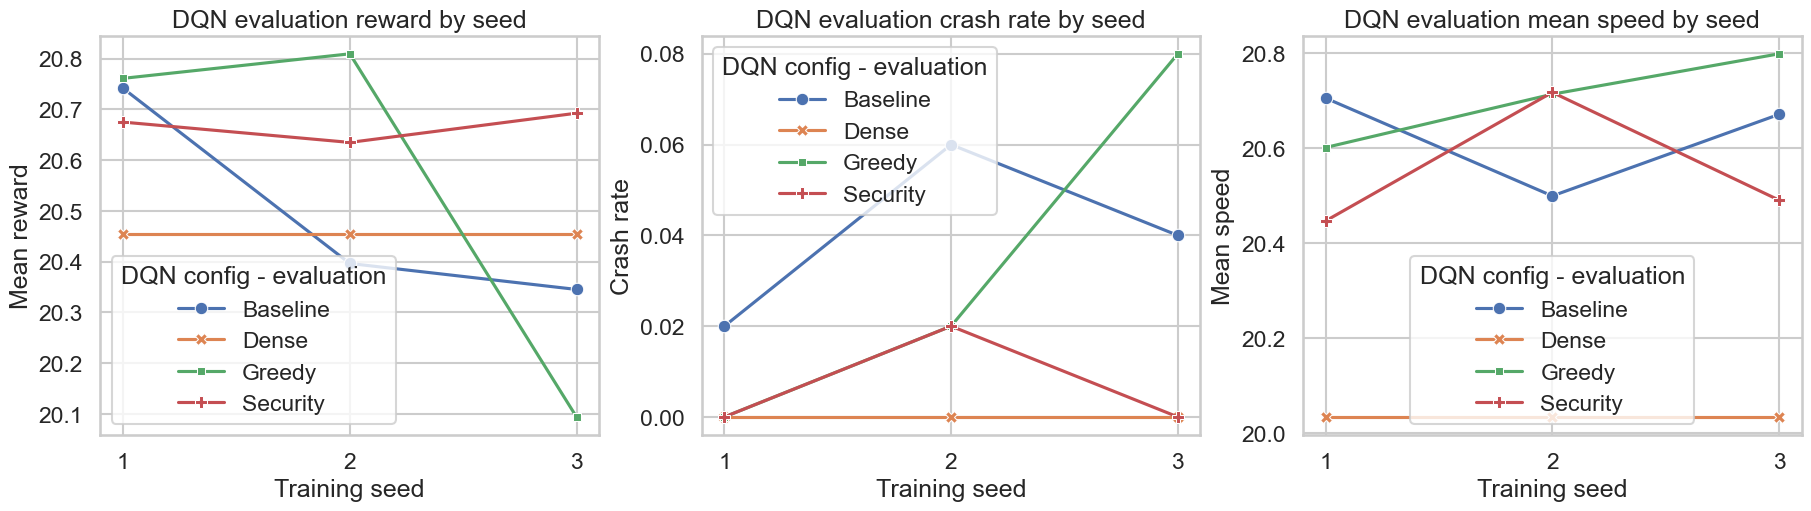

In [13]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

dqn_eval_seed_plot_specs = [
    ("mean_reward", "DQN evaluation reward by seed", "Mean reward"),
    ("crash_rate", "DQN evaluation crash rate by seed", "Crash rate"),
    ("mean_speed", "DQN evaluation mean speed by seed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, dqn_eval_seed_plot_specs):
    sns.lineplot(
        data=dqn_eval_summary_df,
        x="train_seed",
        y=metric,
        hue="config",
        style="config",
        markers=True,
        dashes=False,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(dqn_eval_summary_df["train_seed"].unique()))
    ax.legend(title="DQN config - evaluation")

plt.show()

En évaluation, les écarts entre les configurations DQN sont beaucoup plus faibles que pendant le training. C'est important, car pendant l'entraînement la configuration Dense semblait clairement moins bonne : reward plus faible et crash rate plus élevé. Pourtant, en évaluation, elle devient beaucoup plus stable, avec un crash rate nul sur les trois seeds et des résultats très réguliers.

Greedy obtient de bons rewards sur les seeds 1 et 2, mais chute nettement sur la seed 3. C'est aussi la configuration qui a le crash rate le plus élevé sur cette seed.

Security reste assez régulière et garde un crash rate faible, voire nul sur deux seeds. Même si elle ne domine pas clairement en reward pendant l'évaluation, elle reste un bon compromis entre performance et sécurité.

Baseline est correcte, mais moins stable. On peut voir que son reward baisse entre les seeds, et son crash rate augmente sur les seeds 2 et 3.

La conclusion est donc plus nuancée que pendant le training puisque la config Dense qui semblait faible à l'entraînement se comporte proprement en évaluation. Par conséquent les meilleures configurations en évaluation sont plutôt Dense pour la stabilité et Security pour le compromis global, tandis que Greedy n'a pas vraiment permis de faire évoluer la politique de l'agent vers un comportement plus agressif.

#### Résumé et graphes agrégés de l'évaluation par configuration

,config,n_training_seeds,reward_mean,reward_std_across_seeds,mean_internal_std_reward,episode_length_mean,crash_rate_mean,offroad_rate_mean,mean_speed_mean,n_episodes_mean
0,Baseline,3,20.494,0.215,1.574,29.587,0.040,0.0,20.625,50.0
1,Dense,3,20.455,0.000,0.000,30.000,0.000,0.0,20.034,50.0
2,Greedy,3,20.555,0.400,1.316,29.613,0.033,0.0,20.704,50.0
3,Security,3,20.667,0.030,0.724,29.887,0.007,0.0,20.552,50.0


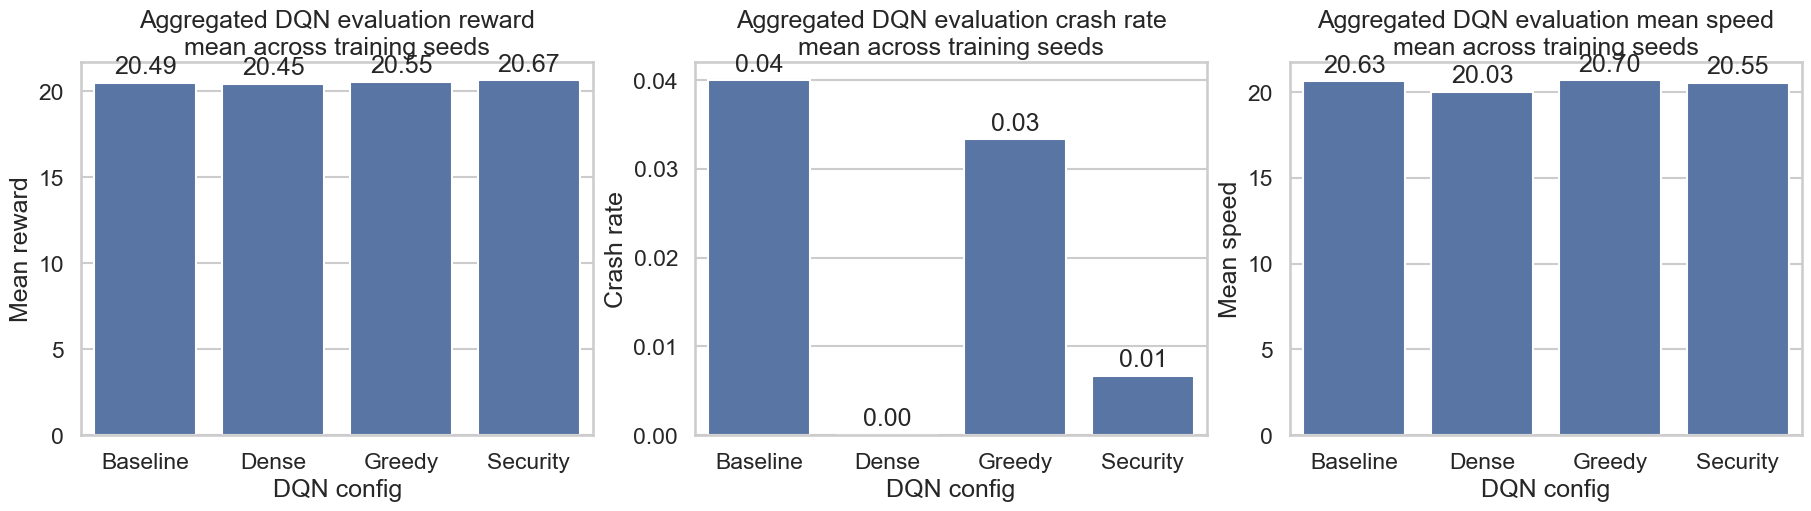

In [14]:
dqn_eval_config_summary = (
    dqn_eval_summary_df.groupby("config", as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        reward_mean=("mean_reward", "mean"),
        reward_std_across_seeds=("mean_reward", "std"),
        mean_internal_std_reward=("std_reward", "mean"),
        episode_length_mean=("mean_episode_length", "mean"),
        crash_rate_mean=("crash_rate", "mean"),
        offroad_rate_mean=("offroad_rate", "mean"),
        mean_speed_mean=("mean_speed", "mean"),
        n_episodes_mean=("n_episodes", "mean"),
    )
    .sort_values("config")
    .fillna(0.0)
)

display(dqn_eval_config_summary.round(3))

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

dqn_eval_aggregate_plot_specs = [
    ("reward_mean", "Aggregated DQN evaluation reward", "Mean reward"),
    ("crash_rate_mean", "Aggregated DQN evaluation crash rate", "Crash rate"),
    ("mean_speed_mean", "Aggregated DQN evaluation mean speed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, dqn_eval_aggregate_plot_specs):
    sns.barplot(
        data=dqn_eval_config_summary,
        x="config",
        y=metric,
        ax=ax,
    )
    ax.set_title(title + "\nmean across training seeds")
    ax.set_xlabel("DQN config")
    ax.set_ylabel(ylabel)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

Les graphes agrégés confirment que les différences entre configurations sont faibles en évaluation. Les rewards moyens sont très proches, autour de 20.4 à 20.7, donc aucune configuration ne domine fortement sur la performance.

La différence la plus nette vient de la sécurité. Dense ne crash pas sur l'évaluation, et Security a aussi un crash rate très faible. Baseline et Greedy restent correctes, mais elles ont davantage de crashes.

La vitesse moyenne varie peu entre les configurations, autour de 20 à 21. Greedy est légèrement plus rapide, mais l'écart reste faible.

Au global, Security obtient le meilleur reward moyen avec très peu de crashes, tandis que Dense est la plus sûre. Cela confirme que l'évaluation donne une conclusion plus nuancée que le training : Dense était faible à l'entraînement, mais elle se comporte bien une fois évaluée.


#### Etude de la meilleure configuration selon reward et sécurité

In [15]:
dqn_eval_config_ranking = dqn_eval_config_summary.copy()

dqn_eval_config_ranking["reward_rank"] = dqn_eval_config_ranking["reward_mean"].rank(
    ascending=False,
    method="min",
)
dqn_eval_config_ranking["safety_rank"] = dqn_eval_config_ranking["crash_rate_mean"].rank(
    ascending=True,
    method="min",
)
dqn_eval_config_ranking["speed_rank"] = dqn_eval_config_ranking["mean_speed_mean"].rank(
    ascending=False,
    method="min",
)

dqn_eval_config_ranking["overall_rank_score"] = (
    dqn_eval_config_ranking["reward_rank"]
    + dqn_eval_config_ranking["safety_rank"]
    + dqn_eval_config_ranking["speed_rank"]
)

dqn_eval_config_ranking = dqn_eval_config_ranking.sort_values(
    ["overall_rank_score", "reward_rank", "safety_rank"],
)

display(
    dqn_eval_config_ranking[
        [
            "config",
            "reward_mean",
            "crash_rate_mean",
            "mean_speed_mean",
            "reward_rank",
            "safety_rank",
            "speed_rank",
            "overall_rank_score",
        ]
    ].round(3),
)

,config,reward_mean,crash_rate_mean,mean_speed_mean,reward_rank,safety_rank,speed_rank,overall_rank_score
3,Security,20.667,0.007,20.552,1.0,2.0,3.0,6.0
2,Greedy,20.555,0.033,20.704,2.0,3.0,1.0,6.0
0,Baseline,20.494,0.040,20.625,3.0,4.0,2.0,9.0
1,Dense,20.455,0.000,20.034,4.0,1.0,4.0,9.0


Ce classement montre qu'aucune configuration ne domine sur tous les critères.

Security arrive en tête avec le meilleur reward moyen et un crash rate très faible. C'est donc le meilleur compromis global entre performance et sécurité.

Greedy a le même score global, grâce à la meilleure vitesse moyenne et un bon reward, mais il crash plus souvent que Security. Il est donc plus intéressant si on privilégie la vitesse, mais moins sûr.

Dense est la configuration la plus sûre, avec aucun crash, mais elle a le reward et la vitesse les plus faibles. Baseline reste correcte, mais elle n'est meilleure sur aucun critère.

Au final, Security est la configuration la plus équilibrée pour DQN, tandis que Dense est à privilégier seulement si l'objectif principal est d'éviter les crashes.

## Etude de l'extension complète
***

### Training

,series,seed,mean_reward,crash_rate,mean_speed,observed_steps,observed_episodes
0,2DQN - Baseline,1,19.783,0.111,20.996,200000,7059
1,2DQN - Baseline,2,19.683,0.124,21.041,200000,7105
2,2DQN - Baseline,3,19.795,0.111,21.006,200000,7058
3,DQN - Baseline,1,19.775,0.103,20.912,200000,7040
4,DQN - Baseline,2,19.867,0.096,20.963,200000,7024
5,DQN - Baseline,3,19.870,0.102,20.924,200000,7016
6,DQN - Dense,1,13.774,0.443,20.372,200000,8194
7,DQN - Dense,2,13.840,0.433,20.390,200000,8150
8,DQN - Dense,3,13.609,0.432,20.234,170512,7001
9,DQN - Greedy,1,20.168,0.101,20.954,200000,7014


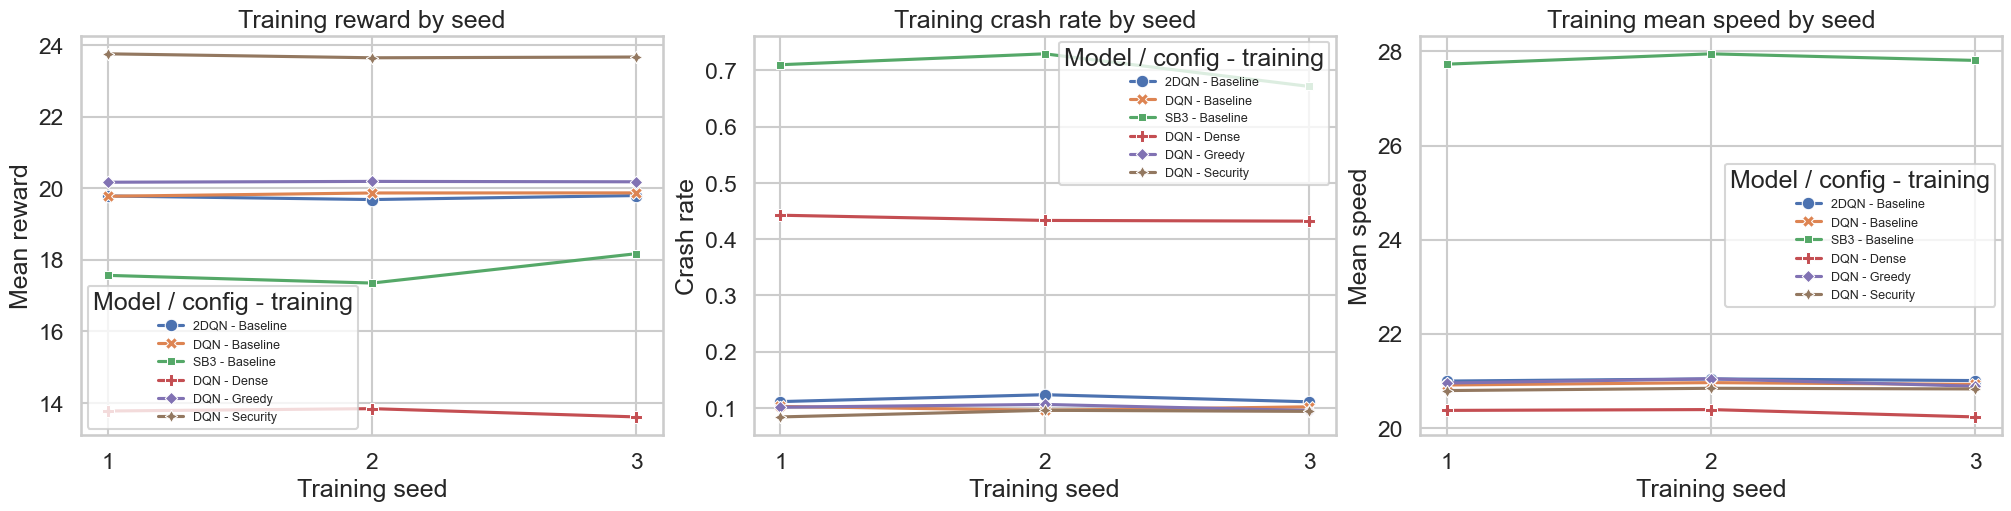

In [16]:
extension_training_plot_df = training_summary[
    (
        (training_summary["model"] == "DQN")
        & (training_summary["config"].isin(["Baseline", "Greedy", "Dense", "Security"]))
    )
    | (
        (training_summary["model"].isin(["SB3", "2DQN"]))
        & (training_summary["config"] == "Baseline")
    )
].copy()

extension_training_plot_df["series"] = (
    extension_training_plot_df["model"] + " - " + extension_training_plot_df["config"]
)


display(
    extension_training_plot_df[
        [
            "series",
            "seed",
            "mean_reward",
            "crash_rate",
            "mean_speed",
            "observed_steps",
            "observed_episodes",
        ]
    ]
    .sort_values(["series", "seed"])
    .round(3),
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

plot_specs = [
    ("mean_reward", "Training reward by seed", "Mean reward"),
    ("crash_rate", "Training crash rate by seed", "Crash rate"),
    ("mean_speed", "Training mean speed by seed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    sns.lineplot(
        data=extension_training_plot_df,
        x="seed",
        y=metric,
        hue="series",
        style="series",
        markers=True,
        dashes=False,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(extension_training_plot_df["seed"].unique()))
    ax.legend(title="Model / config - training", fontsize=9)

plt.show()

Ce graphe permet de situer les extensions pendant l'entraînement par rapport aux deux références (DQN baseline et SB3 baseline). Il est important de noter comme precedemment,que toutes les configurations ne sont pas strictement comparables, car elle reposent sur des reward différents ce qui influence directement les valeurs observées. Malgré cela, le graphe met en évidence plusieurs tendances intéressantes.

Tout d'abord on peut remarquer que l'extensions la plus interessante par rapport a son environnement de training est DQN security. En effet elle depase nettement les reward de DQN baseline et 2DQN tout en gardant un crash rate tres faible et une vitesse similaire. Cet ecart s'explique par la configuration en elle meme qui favorise une conduite prudente et donc explique cette augmentation de reward pour un meme comportement.

Par ailleurs on peut observer que notre algorithme de double DQN ne change pas significativement le comportement de notre DQN from scratch pendant le training puisque l'on peut clairement remarquer que ce dernier opte pour une politique similaire à celle de notre DQN de base (une conduite prudente).

Enfin on peut voir encore une fois que SB3 baseline reste à part et roule beaucoup plus vite, mais avec un crash rate très élevé et que c'est le seul agent qui opte pour une strétégie plus risquée.


### Evaluation

,series,train_seed,mean_reward,crash_rate,mean_speed,n_episodes
0,2DQN - Baseline,1,20.732,0.00,20.550,50
1,2DQN - Baseline,2,20.797,0.00,20.649,50
2,2DQN - Baseline,3,20.736,0.00,20.547,50
3,DQN - Baseline,1,20.741,0.02,20.705,50
4,DQN - Baseline,2,20.396,0.06,20.499,50
5,DQN - Baseline,3,20.345,0.04,20.671,50
6,DQN - Dense,1,20.455,0.00,20.034,50
7,DQN - Dense,2,20.455,0.00,20.034,50
8,DQN - Dense,3,20.455,0.00,20.034,50
9,DQN - Greedy,1,20.761,0.00,20.601,50


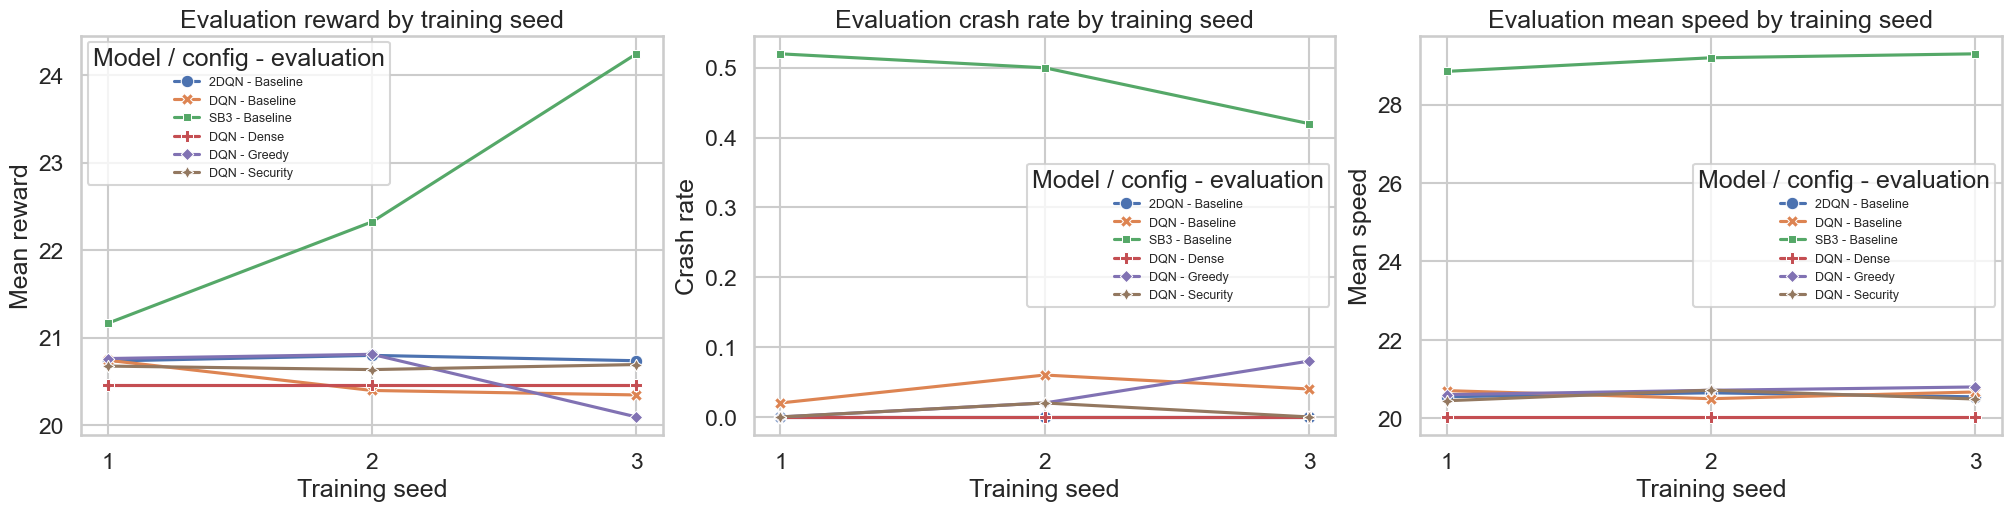

In [17]:
extension_evaluation_plot_df = evaluation_summary_df[
    (
        (evaluation_summary_df["model"] == "DQN")
        & (evaluation_summary_df["config"].isin(["Baseline", "Greedy", "Dense", "Security"]))
    )
    | (
        (evaluation_summary_df["model"].isin(["SB3", "2DQN"]))
        & (evaluation_summary_df["config"] == "Baseline")
    )
].copy()

extension_evaluation_plot_df["series"] = (
    extension_evaluation_plot_df["model"] + " - " + extension_evaluation_plot_df["config"]
)

display(
    extension_evaluation_plot_df[
        [
            "series",
            "train_seed",
            "mean_reward",
            "crash_rate",
            "mean_speed",
            "n_episodes",
        ]
    ]
    .sort_values(["series", "train_seed"])
    .round(3),
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

plot_specs = [
    ("mean_reward", "Evaluation reward by training seed", "Mean reward"),
    ("crash_rate", "Evaluation crash rate by training seed", "Crash rate"),
    ("mean_speed", "Evaluation mean speed by training seed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    sns.lineplot(
        data=extension_evaluation_plot_df,
        x="train_seed",
        y=metric,
        hue="series",
        style="series",
        markers=True,
        dashes=False,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(extension_evaluation_plot_df["train_seed"].unique()))
    ax.legend(title="Model / config - evaluation", fontsize=9)

plt.show()

Ce graphe confirme la tendance observée plus tôt, mais sur l'ensemble des extensions. Par ailleurs il est important de noter qu'il n'y a plus de problème de comparaison lié aux configurations différentes puisque l'evaluation a été effectuée dans les memes conditions.

On peut donc remarquer que SB3 reste le meilleur agent avec le  meilleur reward et la meilleure vitesse, mais avec crash rate largement supérieur. À l'inverse, les variantes de notre DQN restent groupées autour de 20-21 en reward et en vitesse, avec beaucoup moins de crashes.

Par rapport au training, l'écart de Security se réduit et ne domine plus autant en reward ce qui est logique puisque la configuration d'evaluation favorise moins une conduite passive.

On peut donc remarquer que l'extension améliore surtout la sécurité et la robustesse du DQN, mais ne change pas fondamentalement le comportement de l'agent. Globalement, SB3 reste plus performant et plus risqué, tandis que les variantes DQN restent plus prudentes.


## Etude d'un cas d'échec et interprétation
***

Nous avons choisi un cas d'échec qui illustre cette différence vitesse/sécurité.
Sur ce cas, on compare DQN, 2DQN et SB3 dans les mêmes conditions : configuration baseline, seed d'entraînement 3 et seed d'évaluation 51.


### Préparer les données d'évaluation:

In [18]:
failure_pattern = re.compile(
    r"^evaluation_(?P<model>[^_]+)_(?P<config>[^_]+)_seed_(?P<train_seed>\d+)_.*_df$",
)

MODEL_TYPE_BY_LABEL = {
    "DQN": ModelType.DQN,
    "SB3": ModelType.SB3,
    "2DQN": ModelType.DOUBLE_DQN,
}
FAILURE_MODELS = ["DQN", "SB3", "2DQN"]
FAILURE_METRICS = ["reward", "length", "crashed", "offroad", "mean_speed"]

failure_runs = []
for dataframe_name, df in loaded_dataframes.items():
    match = failure_pattern.match(dataframe_name)
    if match is None:
        continue

    metadata = match.groupdict()
    failure_df = df.copy()
    failure_df["model"] = metadata["model"].upper()
    failure_df["config"] = metadata["config"].capitalize()
    failure_df["train_seed"] = int(metadata["train_seed"])
    failure_runs.append(failure_df)

if not failure_runs:
    raise ValueError("No evaluation dataframe available to identify a failure case.")

failure_history = pd.concat(failure_runs, ignore_index=True)
failure_history[["crashed", "offroad"]] = failure_history[["crashed", "offroad"]].astype(float)

paired_episode_case = failure_history.pivot_table(
    index=["config", "train_seed", "seed", "episode"],
    columns="model",
    values=FAILURE_METRICS,
).reset_index()

paired_episode_case.columns = [
    f"{metric}_{model}" if model else metric for metric, model in paired_episode_case.columns
]

required_model_columns = [
    f"{metric}_{model}" for model in FAILURE_MODELS for metric in FAILURE_METRICS
]
missing_columns = [
    column for column in required_model_columns if column not in paired_episode_case.columns
]
if missing_columns:
    raise ValueError(f"Missing required model columns: {missing_columns}")

paired_episode_case = paired_episode_case.dropna(subset=required_model_columns).copy()

paired_episode_case[[f"failure_intensity_{model.lower()}" for model in FAILURE_MODELS]] = (
    pd.DataFrame(
        {
            f"failure_intensity_{model.lower()}": (
                3 * paired_episode_case[f"crashed_{model}"]
                + 2 * paired_episode_case[f"offroad_{model}"]
                + (30 - paired_episode_case[f"length_{model}"]) / 30
                + (
                    paired_episode_case[f"reward_{model}"].max()
                    - paired_episode_case[f"reward_{model}"]
                )
                / max(
                    1e-9,
                    float(
                        paired_episode_case[[f"reward_{m}" for m in FAILURE_MODELS]].stack().std(),
                    ),
                )
            )
            for model in FAILURE_MODELS
        },
    )
)

display(paired_episode_case.head().round(3))

,config,train_seed,seed,episode,crashed_2DQN,crashed_DQN,crashed_SB3,length_2DQN,length_DQN,length_SB3,...,mean_speed_SB3,offroad_2DQN,offroad_DQN,offroad_SB3,reward_2DQN,reward_DQN,reward_SB3,failure_intensity_dqn,failure_intensity_sb3,failure_intensity_2dqn
0,Baseline,1,1,0,0.0,0.0,0.0,30.0,30.0,30.0,...,29.632,0.0,0.0,0.0,20.881,20.796,29.543,0.501,0.078,0.242
1,Baseline,1,2,1,0.0,0.0,0.0,30.0,30.0,30.0,...,29.966,0.0,0.0,0.0,20.969,20.797,29.941,0.501,0.002,0.225
2,Baseline,1,3,2,0.0,0.0,0.0,30.0,30.0,30.0,...,29.966,0.0,0.0,0.0,20.796,20.882,29.938,0.485,0.003,0.258
3,Baseline,1,4,3,0.0,0.0,0.0,30.0,30.0,30.0,...,29.966,0.0,0.0,0.0,21.055,21.143,29.934,0.436,0.003,0.209
4,Baseline,1,5,4,0.0,0.0,0.0,30.0,30.0,30.0,...,29.467,0.0,0.0,0.0,20.970,21.055,29.340,0.452,0.116,0.225


### Sélection automatique d'un cas d'échec

In [19]:
failure_outcome_columns = [
    *[f"crashed_{model}" for model in FAILURE_MODELS],
    *[f"offroad_{model}" for model in FAILURE_MODELS],
]
intensity_columns = [f"failure_intensity_{model.lower()}" for model in FAILURE_MODELS]

one_sided_failures = paired_episode_case[
    paired_episode_case[failure_outcome_columns].nunique(axis=1) > 1
].copy()

if not one_sided_failures.empty:
    one_sided_failures["decision_score"] = one_sided_failures[intensity_columns].max(axis=1)
    failure_case = one_sided_failures.sort_values("decision_score", ascending=False).iloc[0]
    comparison_label = "one-sided failure"
else:
    shared_failures = paired_episode_case[
        paired_episode_case[failure_outcome_columns].eq(1).any(axis=1)
    ].copy()

    if shared_failures.empty:
        shared_failures = paired_episode_case.copy()

    shared_failures["decision_score"] = shared_failures[intensity_columns].mean(axis=1)
    failure_case = shared_failures.sort_values("decision_score", ascending=False).iloc[0]
    comparison_label = "shared hard case"

focus_model = max(
    FAILURE_MODELS,
    key=lambda model: failure_case[f"failure_intensity_{model.lower()}"],
)

other_model = max(
    [model for model in FAILURE_MODELS if model != focus_model],
    key=lambda model: abs(failure_case[f"reward_{focus_model}"] - failure_case[f"reward_{model}"]),
)

failure_env_type = EnvType[failure_case["config"].upper()]
failure_model_type = MODEL_TYPE_BY_LABEL[focus_model]
failure_train_seed = int(failure_case["train_seed"])
failure_eval_seed = int(failure_case["seed"])

print(
    f"Selected failure case: {comparison_label} | "
    f"config={failure_case['config']} | "
    f"train_seed={failure_train_seed} | "
    f"eval_seed={failure_eval_seed} | "
    f"episode={int(failure_case['episode'])} | "
    f"focus_model={focus_model}",
)

Selected failure case: one-sided failure | config=Baseline | train_seed=3 | eval_seed=51 | episode=48 | focus_model=SB3


### Résumé du cas : 

In [20]:
failure_case_plot = pd.DataFrame(
    [
        {
            "model": model,
            "reward": float(failure_case[f"reward_{model}"]),
            "length": float(failure_case[f"length_{model}"]),
            "crashed": bool(failure_case[f"crashed_{model}"]),
            "offroad": bool(failure_case[f"offroad_{model}"]),
            "mean_speed": float(failure_case[f"mean_speed_{model}"]),
            "failure_intensity": float(failure_case[f"failure_intensity_{model.lower()}"]),
        }
        for model in FAILURE_MODELS
    ],
)

failure_case_plot["status"] = np.select(
    [failure_case_plot["crashed"], failure_case_plot["offroad"]],
    ["Crash", "Offroad"],
    default="Completed",
)

same_case_context = failure_history[
    (failure_history["config"] == failure_case["config"])
    & (failure_history["train_seed"] == int(failure_case["train_seed"]))
    & (failure_history["model"].isin(FAILURE_MODELS))
].copy()

context_by_model = (
    same_case_context.groupby("model", as_index=False)
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        crash_rate=("crashed", "mean"),
        mean_speed_mean=("mean_speed", "mean"),
        length_mean=("length", "mean"),
    )
    .fillna(0.0)
)

failure_case_plot = failure_case_plot.merge(context_by_model, on="model", how="left")
failure_case_plot["reward_gap_vs_model_mean"] = (
    failure_case_plot["reward"] - failure_case_plot["reward_mean"]
)
failure_case_plot["reward_z_score"] = (
    failure_case_plot["reward_gap_vs_model_mean"]
    / failure_case_plot["reward_std"].replace(0.0, np.nan)
).fillna(0.0)

display(failure_case_plot.round(3))

,model,reward,length,crashed,offroad,mean_speed,failure_intensity,status,reward_mean,reward_std,crash_rate,mean_speed_mean,length_mean,reward_gap_vs_model_mean,reward_z_score
0,DQN,20.540,30.0,False,False,20.201,0.550,Completed,20.345,2.462,0.04,20.671,29.34,0.195,0.079
1,SB3,0.985,2.0,True,False,25.867,9.425,Crash,24.241,8.233,0.42,29.294,24.96,-23.256,-2.825
2,2DQN,20.711,30.0,False,False,20.534,0.274,Completed,20.736,0.279,0.00,20.547,30.00,-0.025,-0.091


Sur ce cas, DQN et 2DQN terminent l'épisode sans crash, alors que SB3 échoue.

DQN obtient un reward d'environ 20.54, avec une vitesse moyenne autour de 20.20. 2DQN a un comportement très proche : il termine aussi les 30 steps sans crash, avec un reward légèrement plus élevé, autour de 20.71, et une vitesse moyenne autour de 20.53. Les deux modèles restent donc prudents et évitent la collision.

SB3, au contraire, roule plus vite, avec une vitesse moyenne autour de 25.87 sur cet épisode, mais il crash très tôt. Son reward chute fortement par rapport à sa moyenne habituelle : l'écart est d'environ -23.26. Cela confirme que ce cas est un vrai échec pour SB3.

Ce cas illustre donc clairement le compromis observé précédemment : SB3 adopte une conduite plus rapide mais plus risquée, tandis que DQN et 2DQN restent plus conservateurs et plus sûrs dans cette situation.

### Graphes:

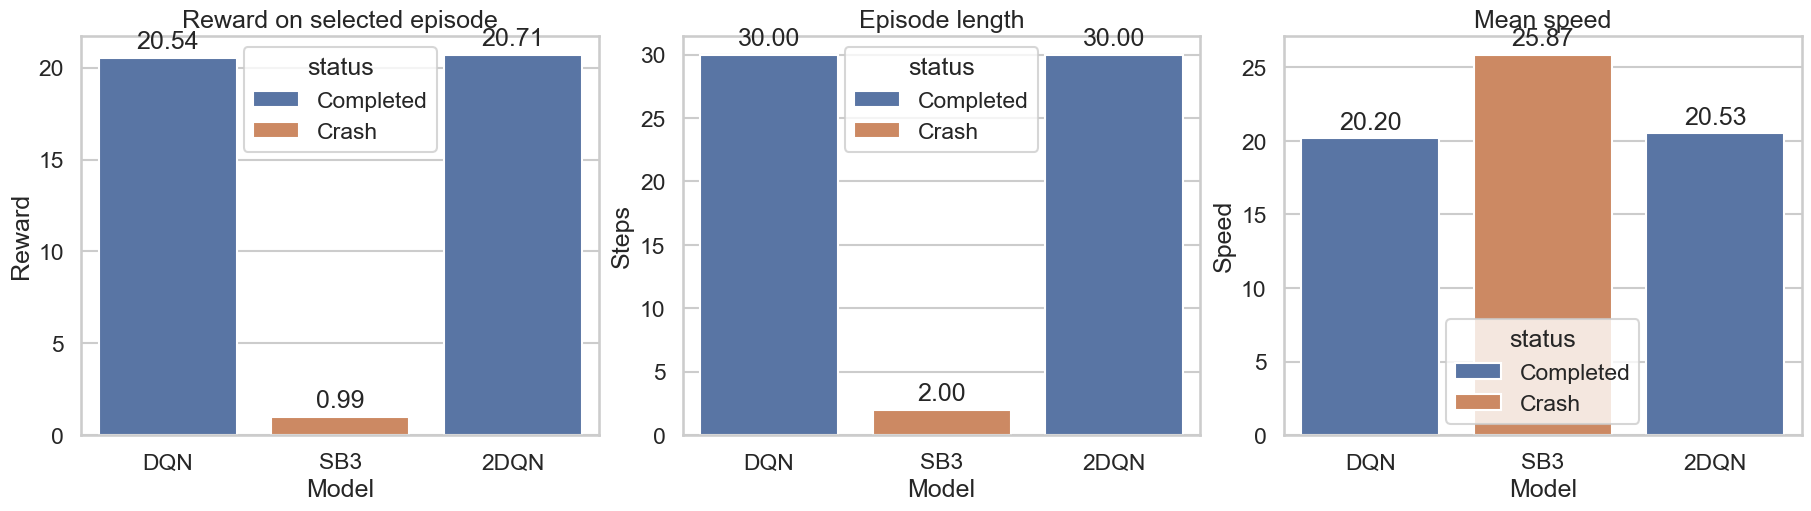

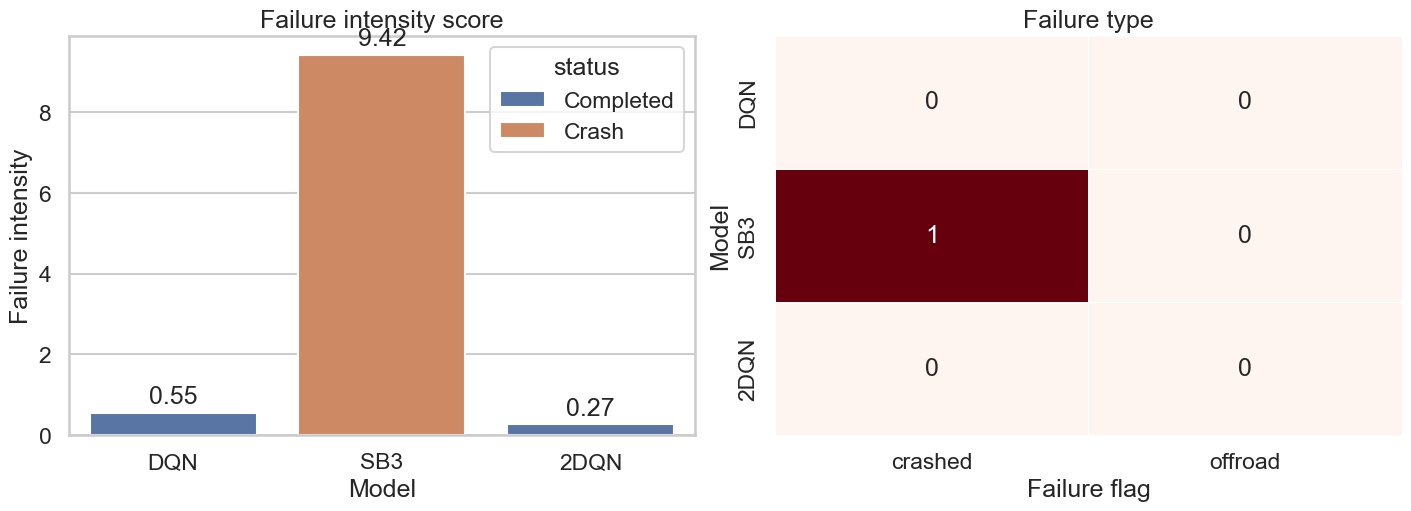

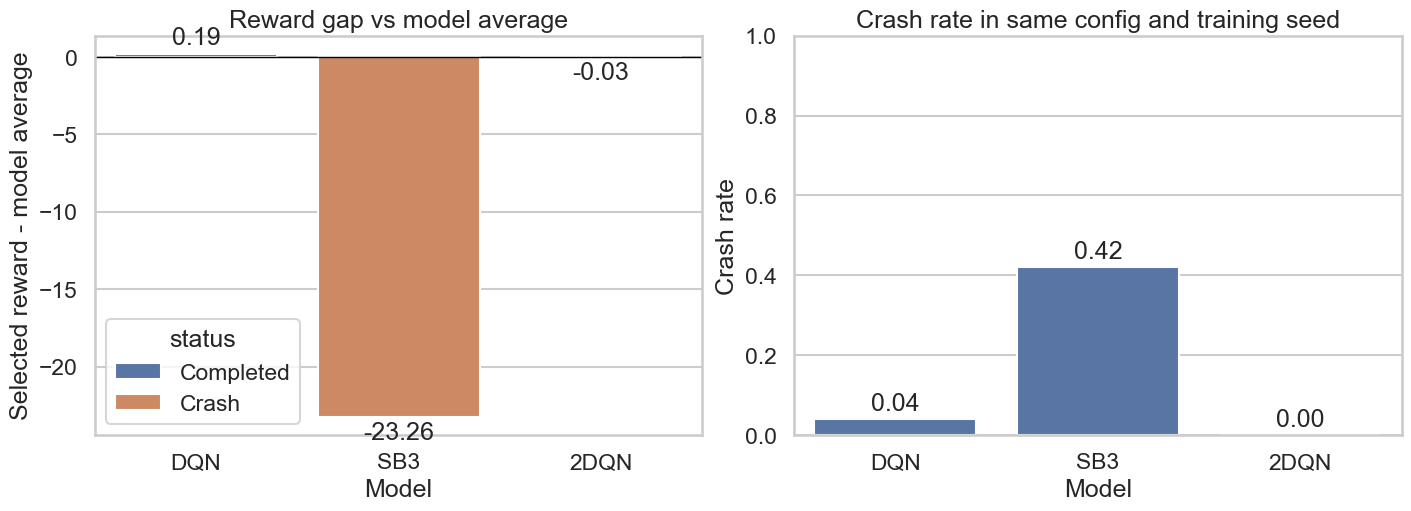

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, metric, title, ylabel in [
    (axes[0], "reward", "Reward on selected episode", "Reward"),
    (axes[1], "length", "Episode length", "Steps"),
    (axes[2], "mean_speed", "Mean speed", "Speed"),
]:
    sns.barplot(
        data=failure_case_plot,
        x="model",
        y=metric,
        hue="status",
        dodge=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=failure_case_plot,
    x="model",
    y="failure_intensity",
    hue="status",
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("Failure intensity score")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Failure intensity")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

failure_flags = failure_case_plot.set_index("model")[["crashed", "offroad"]].astype(int)
sns.heatmap(
    failure_flags,
    annot=True,
    cmap="Reds",
    cbar=False,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("Failure type")
axes[1].set_xlabel("Failure flag")
axes[1].set_ylabel("Model")

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=failure_case_plot,
    x="model",
    y="reward_gap_vs_model_mean",
    hue="status",
    dodge=False,
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Reward gap vs model average")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Selected reward - model average")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=failure_case_plot,
    x="model",
    y="crash_rate",
    ax=axes[1],
)
axes[1].set_title("Crash rate in same config and training seed")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Crash rate")
axes[1].set_ylim(0, 1)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

plt.show()

Ces graphes servent surtout à visualiser l'écart du cas d'échec : SB3 est le seul modèle qui crash, avec une durée d'épisode très courte et un score d'échec nettement plus élevé.

Ils montrent aussi que cet épisode est anormalement mauvais pour SB3 par rapport à sa moyenne, alors que DQN et 2DQN restent proches de leur comportement habituel.

### Visualisation : 

#### SB3

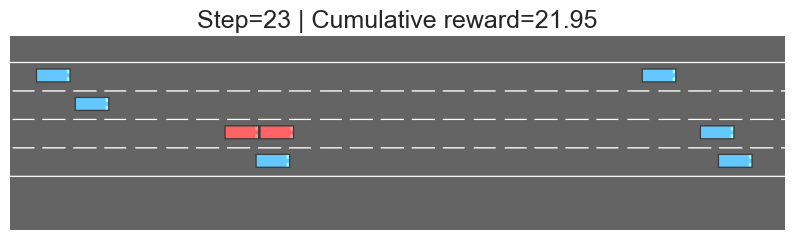

,model,config,train_seed,eval_seed,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,SB3,baseline,3,51,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,21.953471,23,True,False,29.292652


In [22]:
env_id, env_config = get_env_config(failure_env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)

env = benchmark.make_env(seed=failure_eval_seed)
model_path = resolve_model_path(
    project_root=project_root,
    model_type=failure_model_type,
    env_type=failure_env_type,
    train_seed=failure_train_seed,
)

model = load_model(failure_model_type, model_path)

failure_stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)

env.close()

pd.DataFrame(
    [
        {
            "model": focus_model,
            "config": failure_env_type.value,
            "train_seed": failure_train_seed,
            "eval_seed": failure_eval_seed,
            "model_path": str(model_path),
            **failure_stats,
        },
    ],
)

#### DQN

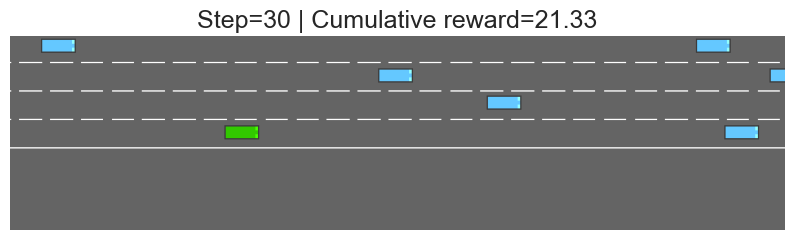

,model,config,train_seed,eval_seed,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,DQN,baseline,3,51,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,21.334149,30,False,False,21.367685


In [23]:
dqn_failure_model_type = ModelType.DQN
dqn_focus_model = "DQN"

env_id, env_config = get_env_config(failure_env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)

env = benchmark.make_env(seed=failure_eval_seed)
model_path = resolve_model_path(
    project_root=project_root,
    model_type=dqn_failure_model_type,
    env_type=failure_env_type,
    train_seed=failure_train_seed,
)

model = load_model(dqn_failure_model_type, model_path)

dqn_failure_stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)

env.close()

pd.DataFrame(
    [
        {
            "model": dqn_focus_model,
            "config": failure_env_type.value,
            "train_seed": failure_train_seed,
            "eval_seed": failure_eval_seed,
            "model_path": str(model_path),
            **dqn_failure_stats,
        },
    ],
)

#### 2DQN

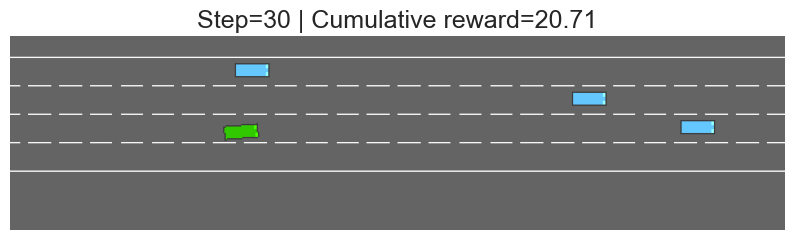

,model,config,train_seed,eval_seed,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,2DQN,baseline,3,51,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,20.710646,30,False,False,20.534327


In [24]:
double_dqn_failure_model_type = ModelType.DOUBLE_DQN
double_dqn_focus_model = "2DQN"

env_id, env_config = get_env_config(failure_env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)

env = benchmark.make_env(seed=failure_eval_seed)
model_path = resolve_model_path(
    project_root=project_root,
    model_type=double_dqn_failure_model_type,
    env_type=failure_env_type,
    train_seed=failure_train_seed,
)

model = load_model(double_dqn_failure_model_type, model_path)

double_dqn_failure_stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)

env.close()

pd.DataFrame(
    [
        {
            "model": double_dqn_focus_model,
            "config": failure_env_type.value,
            "train_seed": failure_train_seed,
            "eval_seed": failure_eval_seed,
            "model_path": str(model_path),
            **double_dqn_failure_stats,
        },
    ],
)

Ce cas illustre donc bien le compromis entre les modèles : SB3 est plus rapide et plus agressif, mais moins sûr. Le DQN est moins rapide, mais plus stable dans cette situation, car il évite l'accident. 2DQN évite aussi le crash, mais son comportement est moins propre visuellement : il effectue beaucoup de changements de file qui ne semblent pas toujours justifiés. Comme sa vitesse reste faible, ces manœuvres ne provoquent pas d'accident, mais elles montrent une politique moins fluide que celle attendue.

## Analyse du comportement du modèle à partir d'un rollout sélectionné
***

pour train_seed = 3 et eval_seed = 34, les trois modèles finissent sans crash, mais SB3 roule beaucoup plus vite :

DQN  reward ≈ 20.455, vitesse ≈ 20.034  

SB3  reward ≈ 29.934, vitesse ≈ 29.966  

2DQN reward ≈ 20.882, vitesse ≈ 20.868  



Viusualisation SB3:

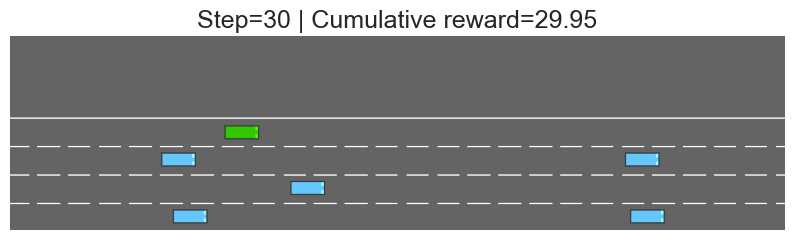

,model,config,train_seed,eval_seed,checkpoint,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,SB3,baseline,3,34,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,29.949761,30,False,False,29.965648


In [ ]:
selected_env_type = EnvType.BASELINE
selected_model_type = ModelType.SB3
selected_train_seed = 3
selected_eval_seed = 34
selected_checkpoint = None


def run_selected_rollout(model_type: ModelType, model_label: str) -> dict:
    env_id, env_config = get_env_config(selected_env_type)
    env_config["offscreen_rendering"] = True

    benchmark = HighwayBenchmark(
        config=BenchmarkConfig(
            env_id=env_id,
            env_config=env_config,
        ),
        render_mode="rgb_array",
    )

    env = benchmark.make_env(seed=selected_eval_seed)
    model_path = resolve_model_path(
        project_root=project_root,
        model_type=model_type,
        env_type=selected_env_type,
        train_seed=selected_train_seed,
        checkpoint=selected_checkpoint,
    )
    model = load_model(model_type, model_path)

    rollout_stats = display_episode(
        env=env,
        model=model,
        greedy=True,
        sleep_time=0.03,
    )

    env.close()

    return {
        "model": model_label,
        "config": selected_env_type.value,
        "train_seed": selected_train_seed,
        "eval_seed": selected_eval_seed,
        "checkpoint": selected_checkpoint,
        "model_path": str(model_path),
        **rollout_stats,
    }


sb3_rollout_stats = run_selected_rollout(selected_model_type, "SB3")

pd.DataFrame([sb3_rollout_stats])

Visualisation DQN : 

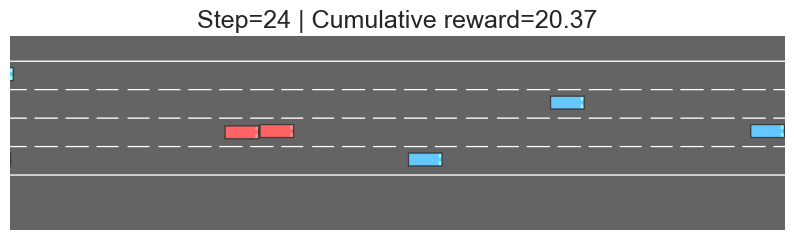

,model,config,train_seed,eval_seed,checkpoint,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,DQN,baseline,3,34,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,20.367585,24,True,False,26.69149


In [ ]:
dqn_rollout_stats = run_selected_rollout(ModelType.DQN, "DQN")

pd.DataFrame([dqn_rollout_stats])

Visualisation 2DQN : 


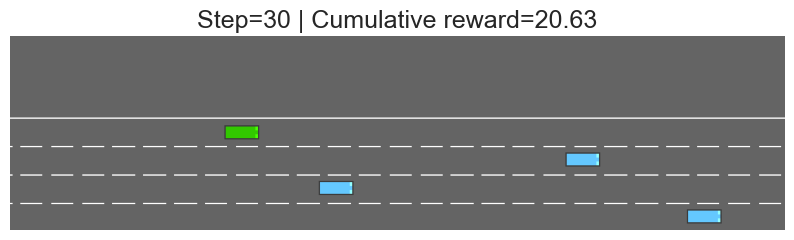

,model,config,train_seed,eval_seed,checkpoint,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,2DQN,baseline,3,34,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,20.626989,30,False,False,20.367685


In [ ]:
double_dqn_rollout_stats = run_selected_rollout(ModelType.DOUBLE_DQN, "2DQN")

pd.DataFrame([double_dqn_rollout_stats])

Tableau final : 

In [ ]:
rollout_comparison_table = pd.DataFrame(
    [
        sb3_rollout_stats,
        dqn_rollout_stats,
        double_dqn_rollout_stats,
    ],
)

rollout_comparison_table[
    [
        "model",
        "config",
        "train_seed",
        "eval_seed",
        "episode_reward",
        "episode_length",
        "crashed",
        "offroad",
        "mean_speed",
        "checkpoint",
        "model_path",
    ]
].round(3)

,model,config,train_seed,eval_seed,episode_reward,episode_length,crashed,offroad,mean_speed,checkpoint,model_path
0,SB3,baseline,3,34,29.950,30,False,False,29.966,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...
1,DQN,baseline,3,34,20.368,24,True,False,26.691,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...
2,2DQN,baseline,3,34,20.627,30,False,False,20.368,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...


Pour ce rollout, les trois modèles sont évalués dans les mêmes conditions : configuration baseline, seed d'entraînement 3 et seed d'évaluation 34.

SB3 obtient le meilleur résultat sur cet épisode. Il termine les 30 steps sans crash ni sortie de route, avec un reward de 29.950 et une vitesse moyenne très élevée de 29.966. Visuellement, son comportement est aussi le plus fluide : la voiture garde une trajectoire plus stable et les changements de voie sont moins fréquents. Sur cet épisode, SB3 adopte donc une conduite rapide et efficace, sans provoquer d'accident.

DQN a un comportement moins bon sur ce même rollout. Il obtient un reward de 20.368, mais l'épisode s'arrête après 24 steps à cause d'un crash. Sa vitesse moyenne est pourtant assez élevée (26.691), ce qui suggère que le modèle prend plus de risques sans réussir à maintenir une conduite sûre jusqu'à la fin même si il change peu de file. Le seul changement a conduit au crash. Dans ce cas précis, DQN ne parvient pas à gérer correctement la situation de trafic.

2DQN termine l'épisode complet sans crash ni sortie de route, avec un reward de 20.627 et une vitesse moyenne de 20.368. Il est donc plus sûr que DQN sur ce rollout. En revanche, son comportement est beaucoup fluide que celui de SB3 : la voiture effectue beaucoup de changements de file non nécessaire, ce qui donne une conduite très instable. Même si 2DQN évite l'accident, il reste plus prudent et moins performant que SB3 sur cet épisode.

Ce rollout illustre bien les différences entre les modèles. SB3 est le plus performant ici, car il combine vitesse élevée, trajectoire fluide et absence de crash. DQN est plus risqué et finit par crasher. 2DQN est plus sûr que DQN, mais sa conduite est moins fluide et son reward reste proche de celui de DQN, loin derrière SB3.

## Discussion des choix de conception
***

Le projet a été construit pour comparer les modèles de manière progressive. On commence par une configuration baseline commune, puis on compare DQN, Double DQN et SB3 avec les mêmes seeds d'entraînement, les mêmes seeds d'évaluation et les mêmes métriques. Ce choix permet d'isoler au maximum l'effet du modèle, sans mélanger la comparaison avec un changement d'environnement.

Nous avons gardé plusieurs métriques complémentaires : le reward mesure la performance globale, le crash rate et le offroad rate mesurent la sécurité, la vitesse moyenne permet d'interpréter le style de conduite, et la longueur d'épisode indique si le modèle termine réellement les épisodes. C'est important parce qu'un reward plus élevé ne signifie pas forcément une conduite plus sûre. On l'observe notamment avec SB3, qui obtient souvent de meilleurs rewards et une vitesse plus élevée, mais avec davantage de crashs.

L'utilisation de plusieurs seeds est aussi un choix important. Les courbes par seed permettent de voir si un résultat est stable ou s'il dépend d'un entraînement particulier. Les tableaux agrégés donnent ensuite une synthèse plus lisible, mais ils ne remplacent pas l'analyse par seed. C'est pour cela que les deux niveaux sont affichés : d'abord le détail, puis l'agrégation.

Les extensions de configuration ont été choisies pour tester différents comportements. La configuration Greedy pousse davantage le modèle à changer de voie et à optimiser la progression. La configuration Dense rend l'environnement plus difficile en augmentant le trafic. La configuration Security renforce la pénalité liée aux collisions pour favoriser une politique plus prudente. Ces variantes permettent de vérifier si le DQN peut être amélioré par reward shaping, et pas seulement par un changement d'algorithme.

Enfin, les rollouts et les cas d'échec complètent les tableaux. Les métriques globales montrent les tendances, mais elles n'expliquent pas toujours le comportement exact du véhicule. Les visualisations permettent de voir concrètement si un modèle conduit prudemment, s'il change de voie inutilement, ou s'il privilégie la vitesse au détriment de la sécurité. C'est notamment utile pour interpréter le compromis observé entre SB3, plus rapide mais plus risqué, et les modèles DQN/2DQN, plus prudents.

Une limite de cette étude est que certaines interprétations comportementales, comme la fluidité des changements de voie, restent surtout qualitatives à partir des vidéos. Pour aller plus loin, il serait utile d'enregistrer explicitement les actions, la voie du véhicule et les distances aux autres véhicules à chaque step, ce qui permettrait de quantifier plus précisément la stabilité de la conduite. De plus, il aurait été intéressant d'optimiser les hyperparamètres de notre DQN from scratch (par exemple à l'aide d'outils comme Optuna), afin d'identifier une configuration plus adaptée. Une telle optimisation aurait notamment pu permettre à notre implémentation d'apprendre une politique plus agressive et potentiellement plus performante.

Enfin il aurait aussi été interessant de tester d'autres algorithmes de RL, comme PPO, pour voir si le compromis entre performance et sécurité est spécifique à DQN ou s'il se retrouve aussi avec d'autres approches.